<a href="https://colab.research.google.com/github/AndreiAf02/Fourier_Stock_Prediction/blob/main/GSPTSE_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
from keras import ops
from keras import layers

import tensorflow as tf
import random

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from scipy.fft import fft, ifft, fftfreq
import pywt

In [ ]:
## Code adapted from: https://keras.io/examples/nlp/text_classification_with_transformer/
## Additional codes modified from https://github.com/samugit83/TheGradientPath/blob/master/Keras/transformers/time_series_forecast/main.py


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.layernorm2(out1 + ffn_output)

In [ ]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = ops.shape(x)[-1]
        positions = ops.arange(start=0, stop=maxlen, step=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [ ]:
class TransformerEncoder(layers.Layer):
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.enc_layers = [TransformerBlock(embed_dim, num_heads, ff_dim, rate)
                           for _ in range(num_layers)]
        self.dropout = layers.Dropout(rate)

    def call(self, inputs, training=False):
        x = inputs
        x = self.dropout(x, training=training)
        for layer in self.enc_layers:
            x = layer(x, training=training)
        return x

In [ ]:
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data.iloc[i:(i + time_step),:])
        y.append(data.iloc[i + time_step,:])
    X, y = np.array(X), np.array(y)
    # y = y.flatten()
    return X, y

In [ ]:
def model_builder(maxlen, embed_dim, num_heads, ff_dim, dim):
  inputs = layers.Input(shape=(maxlen,dim))
  x = layers.Dense(embed_dim)(inputs)
  encoder = TransformerEncoder(num_layers=8, embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim, rate=0.1)
  x = encoder(x)
  transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
  x = transformer_block(x)
  x = tf.keras.layers.Flatten()(x)
  # x = layers.GlobalAveragePooling1D()(x)
  # x = layers.Dropout(0.1)(x)
  # x = layers.Dense(64, activation="relu")(x)
  x = layers.Dropout(0.1)(x)
  x = layers.Dense(64, activation="relu")(x)
  x = layers.Dropout(0.1)(x)
  outputs = layers.Dense(dim)(x) #layers.Dense(2, activation="softmax")(x)

  model = keras.Model(inputs=inputs, outputs=outputs)
  return model

In [ ]:
def transformer_model(X, y, min_list, max_list, valid_len, test_len, maxlen, embed_dim, num_heads, ff_dim, seed_nr, plot_yes_no):
  random.seed(seed_nr)
  np.random.seed(seed_nr)
  tf.random.set_seed(seed_nr)
  model = model_builder(maxlen, embed_dim, num_heads, ff_dim, y.shape[1])
  X_train = X[:-test_len - valid_len]
  y_train = y[:-test_len - valid_len]

  X_valid = X[-test_len - valid_len:-test_len]
  y_valid = y[-test_len - valid_len:-test_len]

  X_test = X[-test_len:]
  y_test = y[-test_len:]

  model.compile(optimizer="adam", loss="mse", metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')])
  history = model.fit(
      X_train, y_train, batch_size=32, epochs=100, validation_data=(X_valid, y_valid))

  prediction = model.predict(X)
  prediction_df = pd.DataFrame(prediction, columns = cols_list)
  prediction_df.index = stock_data[-len(prediction_df):].index
  prediction_df_rescaled = prediction_df * (max_list - min_list) + min_list

  NRMSE_list = []
  for i in range(len(cols_list)):
      rmse_value = np.sqrt(np.mean(((prediction_df_rescaled[cols_list[i]].iloc[-test_len:] - stock_data[cols_list[i]].iloc[-test_len:]) ** 2)))
      ## Normalize RMSE:
      nrmse_value = rmse_value/(stock_data[cols_list[i]].iloc[-test_len:].max()-stock_data[cols_list[i]].iloc[-test_len:].min())
      NRMSE_list.append(float(nrmse_value))

      if plot_yes_no == 'Yes':
        plt.figure(figsize=(16,6))
        # plt.plot(prediction_df[cols_list[i]], 'r-', label = 'Prediction')
        plt.plot(prediction_df.index, y[:,i], 'b-', label = 'Actual')
        plt.plot(prediction_df[cols_list[i]].iloc[:-test_len - valid_len], 'm-', label = 'Training')
        plt.plot(prediction_df[cols_list[i]].iloc[-test_len - valid_len:-test_len], 'g-', label = 'Validation')
        plt.axhline(y=1, color='k', linestyle='--', linewidth=1)
        plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
        plt.plot(prediction_df[cols_list[i]].iloc[-test_len:], 'r-', label = 'Testing')
        plt.title(f'{stock_symbol} ({cols_list[i]}) - Unscaled', fontsize=12)
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

        plt.figure(figsize=(16,6))
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[:-test_len - valid_len], 'm-', label = 'Training')
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[-test_len - valid_len:-test_len], 'g-', label = 'Validation')
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[-test_len:], 'r-', label = 'Testing')
        plt.plot(stock_data[cols_list[i]], 'b-', label = 'Actual')
        plt.title(f'{stock_symbol} ({cols_list[i]})', fontsize=12)
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

  return NRMSE_list

In [ ]:
def transformer_model_no_data(X, y, min_list, max_list, valid_len, test_len, maxlen, embed_dim, num_heads, ff_dim, seed_nr, plot_yes_no):
  random.seed(seed_nr)
  np.random.seed(seed_nr)
  tf.random.set_seed(seed_nr)
  model = model_builder(maxlen, embed_dim, num_heads, ff_dim, y.shape[1])
  X_train = X[:-test_len - valid_len]
  y_train = y[:-test_len - valid_len]

  X_valid = X[-test_len - valid_len:-test_len]
  y_valid = y[-test_len - valid_len:-test_len]

  X_test = X[-test_len:]
  y_test = y[-test_len:]

  model.compile(optimizer="adam", loss="mse", metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')])
  history = model.fit(
      X_train, y_train, batch_size=32, epochs=100, validation_data=(X_valid, y_valid))

  prediction = model.predict(X[:-test_len])
  prediction_list = prediction.tolist()

  prediction_test_val_rescaled = prediction* (max_list[time_step+1:-test_len].values - min_list[time_step+1:-test_len].values) + min_list[time_step+1:-test_len].values
  prediction_test_val_rescaled = prediction_test_val_rescaled.tolist()

  prediction_stock_rescaled = stock_data[:-test_len].values.tolist()
  X_test_singular = X[-test_len:-test_len+1]
  prediction_test_rescaled = []
  for _ in range(test_len):
    predicted_value = model.predict(X_test_singular)

    prediction_list.append(predicted_value[0].tolist())

    X_test_singular = np.append(X_test_singular[0,1:],predicted_value, axis=0)
    X_test_singular = np.reshape(X_test_singular, (1, X_test_singular.shape[0],
                                              X_test_singular.shape[1]))

    min_val = np.min(prediction_stock_rescaled[-100:], axis=0)
    max_val = np.max(prediction_stock_rescaled[-100:], axis=0)

    predicted_value_rescaled = predicted_value*(max_val-min_val) + min_val
    prediction_test_rescaled.append(predicted_value_rescaled[0].tolist())
    prediction_stock_rescaled.append(predicted_value_rescaled[0].tolist())

  prediction_df = pd.DataFrame(prediction_list, columns = cols_list)
  prediction_df.index = stock_data[-len(prediction_df):].index

  prediction_total_rescaled = prediction_test_val_rescaled + prediction_test_rescaled
  prediction_df_rescaled = pd.DataFrame(prediction_total_rescaled, columns = cols_list)
  prediction_df_rescaled.index = stock_data[-len(prediction_df_rescaled):].index
  # prediction_df_rescaled = prediction_df * (max_list - min_list) + min_list

  NRMSE_list = []
  for i in range(len(cols_list)):
      rmse_value = np.sqrt(np.mean(((prediction_df_rescaled[cols_list[i]].iloc[-test_len:] - stock_data[cols_list[i]].iloc[-test_len:]) ** 2)))
      ## Normalize RMSE:
      nrmse_value = rmse_value/(stock_data[cols_list[i]].iloc[-test_len:].max()-stock_data[cols_list[i]].iloc[-test_len:].min())
      NRMSE_list.append(float(nrmse_value))

      if plot_yes_no == 'Yes':
        plt.figure(figsize=(16,6))
        # plt.plot(prediction_df[cols_list[i]], 'r-', label = 'Prediction')
        plt.plot(prediction_df.index, y[:,i], 'b-', label = 'Actual')
        plt.plot(prediction_df[cols_list[i]].iloc[:-test_len - valid_len], 'm-', label = 'Training')
        plt.plot(prediction_df[cols_list[i]].iloc[-test_len - valid_len:-test_len], 'g-', label = 'Validation')
        plt.plot(prediction_df[cols_list[i]].iloc[-test_len:], 'r-', label = 'Testing')
        plt.title(f'{stock_symbol} ({cols_list[i]}) - Unscaled', fontsize=12)
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

        plt.figure(figsize=(16,6))
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[:-test_len - valid_len], 'm-', label = 'Training')
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[-test_len - valid_len:-test_len], 'g-', label = 'Validation')
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[-test_len:], 'r-', label = 'Testing')
        plt.plot(stock_data[cols_list[i]], 'b-', label = 'Actual')
        plt.title(f'{stock_symbol} ({cols_list[i]})', fontsize=12)
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

  return NRMSE_list

In [ ]:
def transformer_model_no_data_corrected_init(X, y, min_list, max_list, valid_len, test_len, maxlen, embed_dim, num_heads, ff_dim, seed_nr, plot_yes_no):
  random.seed(seed_nr)
  np.random.seed(seed_nr)
  tf.random.set_seed(seed_nr)
  model = model_builder(maxlen, embed_dim, num_heads, ff_dim, y.shape[1])
  X_train = X[:-test_len - valid_len]
  y_train = y[:-test_len - valid_len]

  X_valid = X[-test_len - valid_len:-test_len]
  y_valid = y[-test_len - valid_len:-test_len]

  X_test = X[-test_len:]
  y_test = y[-test_len:]

  model.compile(optimizer="adam", loss="mse", metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')])
  history = model.fit(
      X_train, y_train, batch_size=32, epochs=100, validation_data=(X_valid, y_valid))

  prediction = model.predict(X[:-test_len])
  prediction_list = prediction.tolist()

  prediction_test_val_rescaled = prediction* (max_list[time_step+1:-test_len].values - min_list[time_step+1:-test_len].values) + min_list[time_step+1:-test_len].values
  prediction_test_val_rescaled = prediction_test_val_rescaled.tolist()

  prediction_value_for_diff = np.array(prediction_test_val_rescaled[-1])
  diff = stock_data.iloc[-test_len-1, :].values - prediction_value_for_diff
  ## Eliminating the volume difference correction:
  diff[-1] = 0

  prediction_stock_rescaled = stock_data[:-test_len].values.tolist()
  X_test_singular = X[-test_len:-test_len+1]
  prediction_test_rescaled = []
  for _ in range(test_len):
    predicted_value = model.predict(X_test_singular)

    prediction_list.append(predicted_value[0].tolist())

    X_test_singular = np.append(X_test_singular[0,1:],predicted_value, axis=0)
    X_test_singular = np.reshape(X_test_singular, (1, X_test_singular.shape[0],
                                              X_test_singular.shape[1]))

    min_val = np.min(prediction_stock_rescaled[-100:], axis=0)
    max_val = np.max(prediction_stock_rescaled[-100:], axis=0)

    predicted_value_rescaled = predicted_value*(max_val-min_val) + min_val + diff
    prediction_test_rescaled.append(predicted_value_rescaled[0].tolist())
    prediction_stock_rescaled.append(predicted_value_rescaled[0].tolist())

  prediction_df = pd.DataFrame(prediction_list, columns = cols_list)
  prediction_df.index = stock_data[-len(prediction_df):].index

  prediction_total_rescaled = prediction_test_val_rescaled + prediction_test_rescaled
  prediction_df_rescaled = pd.DataFrame(prediction_total_rescaled, columns = cols_list)
  prediction_df_rescaled.index = stock_data[-len(prediction_df_rescaled):].index
  # prediction_df_rescaled = prediction_df * (max_list - min_list) + min_list

  NRMSE_list = []
  for i in range(len(cols_list)):
      rmse_value = np.sqrt(np.mean(((prediction_df_rescaled[cols_list[i]].iloc[-test_len:] - stock_data[cols_list[i]].iloc[-test_len:]) ** 2)))
      ## Normalize RMSE:
      nrmse_value = rmse_value/(stock_data[cols_list[i]].iloc[-test_len:].max()-stock_data[cols_list[i]].iloc[-test_len:].min())
      NRMSE_list.append(float(nrmse_value))

      if plot_yes_no == 'Yes':
        plt.figure(figsize=(16,6))
        # plt.plot(prediction_df[cols_list[i]], 'r-', label = 'Prediction')
        plt.plot(prediction_df.index, y[:,i], 'b-', label = 'Actual')
        plt.plot(prediction_df[cols_list[i]].iloc[:-test_len - valid_len], 'm-', label = 'Training')
        plt.plot(prediction_df[cols_list[i]].iloc[-test_len - valid_len:-test_len], 'g-', label = 'Validation')
        plt.plot(prediction_df[cols_list[i]].iloc[-test_len:], 'r-', label = 'Testing')
        plt.title(f'{stock_symbol} ({cols_list[i]}) - Unscaled', fontsize=12)
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

        plt.figure(figsize=(16,6))
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[:-test_len - valid_len], 'm-', label = 'Training')
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[-test_len - valid_len:-test_len], 'g-', label = 'Validation')
        plt.plot(prediction_df_rescaled[cols_list[i]].iloc[-test_len:], 'r-', label = 'Testing')
        plt.plot(stock_data[cols_list[i]], 'b-', label = 'Actual')
        plt.title(f'{stock_symbol} ({cols_list[i]})', fontsize=12)
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

  return NRMSE_list

## Fourier Denoising functions:

In [ ]:
## Padding-based Fourier Transform, based on Song et al. (2021):
def padding_fourier(stock_data, threshold_list, nr_padding_samples):
  denoised_stock_data = pd.DataFrame()

  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]].reset_index(drop=True)

    ## Creating the padding:
    X1_bar = np.sqrt(np.mean(xt[:20]))
    X2_bar = np.sqrt(np.mean(xt[-20:]))

    sigma1 = np.sqrt(np.mean(xt[:20]-X1_bar))
    sigma2 = np.sqrt(np.mean(xt[-20:]-X2_bar))

    np.random.seed(i)
    N1_list = np.random.normal(loc=0, scale=sigma1, size=nr_padding_samples)
    N2_list = np.random.normal(loc=0, scale=sigma2, size=nr_padding_samples)

    lower_pad_series = pd.Series(np.flip(N1_list.cumsum())+xt.iloc[0])
    upper_pad_series = pd.Series(N1_list.cumsum()+xt.iloc[-1])

    xt = pd.concat([lower_pad_series, xt, upper_pad_series], ignore_index=True)

    fxt = np.fft.fftn(xt)
    index = abs(fxt)> threshold_list[i]
    fxt_clean = fxt*index.T
    xt_clean = np.fft.ifftn(fxt_clean)

    xt_unpadded = xt_clean[nr_padding_samples:-nr_padding_samples]
    denoised_stock_data[stock_data.columns[i]] = xt_unpadded.real

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data

In [ ]:
def fourier_window_renoising(stock_data, threshold_list, window_coeff_list):
  denoised_stock_data = pd.DataFrame()

  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]]
    fxt = np.fft.fftn(xt)
    index = abs(fxt)> threshold_list[i]
    fxt_clean = fxt*index.T
    xt_clean = np.fft.ifftn(fxt_clean)

    index_renoise = abs(fxt)<= threshold_list[i]
    fxt_renoise = fxt*index_renoise.T
    xt_renoise = np.fft.ifftn(fxt_renoise)
    a = window_coeff_list[i]/len(xt_renoise)**2
    date_range = np.linspace(0,len(stock_data)-1,len(stock_data))
    renoise_window = np.maximum(0,a*date_range*(date_range-len(xt_renoise))+1)
    fwr_data = xt_clean+xt_renoise*renoise_window
    denoised_stock_data[stock_data.columns[i]] = fwr_data.real

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data



In [ ]:
def linear_drift_denoising(stock_data, threshold_list):
  denoised_stock_data = pd.DataFrame()

  date_range = np.linspace(0,len(stock_data)-1,len(stock_data))
  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]]
    lin_drift_slope = (xt.iloc[-1] - xt.iloc[0])/len(xt)
    lin_drift = []
    for j in date_range:
      lin_drift.append(float(xt.iloc[0] + lin_drift_slope * j))
    xt_undrifted = xt - lin_drift
    fxt = np.fft.fft(xt_undrifted)
    index = abs(fxt)> threshold_list[i]
    fxt_clean = fxt*index
    xt_clean = np.fft.ifft(fxt_clean)
    xt_clean = xt_clean.real
    xt_clean_redrifted = xt_clean + lin_drift

    denoised_stock_data[stock_data.columns[i]] = xt_clean_redrifted

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data

In [ ]:
def fejer_denoising(stock_data, threshold_list):
  Cesaro_stock_data = pd.DataFrame()
  denoised_stock_data = pd.DataFrame()

  for i in range(len(stock_data.columns)):
    ## Creating the FFT smoothed curve:
    xt = stock_data[stock_data.columns[i]]
    fxt = np.fft.fftn(xt)
    index = abs(fxt)> threshold_list[i]
    fxt_clean = fxt*index.T
    xt_clean = np.fft.ifftn(fxt_clean)
    xt_clean = xt_clean.real

    ## Creating the drift-oriented Fejer summation:
    date_range = np.linspace(0,len(xt)-1,len(xt))
    lin_drift_slope = (xt.iloc[-1] - xt.iloc[0])/len(xt)
    lin_drift = []
    for j in date_range:
      lin_drift.append(float(xt.iloc[0] + lin_drift_slope * j))
    xt_drift = xt
    xt_undrifted = xt_drift - lin_drift

    fxt_undrifted = np.fft.fftn(xt_undrifted)
    fxt_undrifted = np.fft.fftshift(fxt_undrifted)
    index_mtx = np.tril(np.ones((len(fxt_undrifted), len(fxt_undrifted))))
    index_thresh = abs(fxt_undrifted)> threshold_list[i]
    sk_data = {}
    sk_data['PS0'] = np.zeros(len(xt))
    for j in range(len(fxt)):
      index_fej = index_mtx[j].tolist()
      fxt_singular = fxt_undrifted.T * index_fej * index_thresh
      fxt_singular = fxt_singular.T
      fxt_singular = np.fft.ifftshift(fxt_singular)
      xt_singular = np.fft.ifftn(fxt_singular)
      xt_singular = xt_singular.real.T
      sk_data['PS'+str(j+1)] = xt_singular
    sk_df = pd.DataFrame(sk_data)

    Cesaro_data = {}
    for j in range(len(fxt_undrifted)):
      col_list = sk_df.columns[:j+1].tolist()
      Cesaro_data['CM'+str(j+1)] = sk_df[col_list].mean(axis=1)
    Cesaro_df = pd.DataFrame(Cesaro_data)
    Cesaro_stock_data[stock_data.columns[i]] = Cesaro_df.iloc[:,-1] + lin_drift
    Cesaro_results = Cesaro_df.iloc[:,-1] + lin_drift

    ## Combining the two using windowing:
    a = window_coeff_list[i]/len(xt)**2
    fejer_window = np.maximum(0,a*date_range*(date_range-len(xt))+1)
    fft_window = np.minimum(1,-a*date_range*(date_range-len(xt)))

    denoised_stock_data[stock_data.columns[i]] = xt_clean * fft_window + Cesaro_results * fejer_window

  Cesaro_stock_data.index = stock_data.index
  denoised_stock_data.index = stock_data.index
  return denoised_stock_data

In [ ]:
def lanczos_denoising(stock_data, threshold_list):
  Lanczos_stock_data = pd.DataFrame()
  denoised_stock_data = pd.DataFrame()

  for i in range(len(stock_data.columns)):
    ## Creating the FFT smoothed curve:
    xt = stock_data[stock_data.columns[i]]
    fxt = np.fft.fftn(xt)
    Lanczos_factor = [1]
    index = abs(fxt)> threshold_list[i]
    fxt_clean = fxt*index.T
    xt_clean = np.fft.ifftn(fxt_clean)
    xt_clean = xt_clean.real

    ## Creating the Lanczos Sigma-approximation:
    date_range = np.linspace(0,len(xt)-1,len(xt))
    lin_drift_slope = (xt.iloc[-1] - xt.iloc[0])/len(xt)
    lin_drift = []
    for j in date_range:
      lin_drift.append(float(xt.iloc[0] + lin_drift_slope * j))
    xt_drift = xt
    xt_undrifted = xt_drift - lin_drift

    fxt_undrifted = np.fft.fftn(xt_undrifted)
    fxt_undrifted = np.fft.fftshift(fxt_undrifted)

    for k in range(len(fxt_undrifted)-1):
      n = k+1
      sigma_factor = np.sin(n*np.pi/len(fxt_undrifted))/(n*np.pi/len(fxt_undrifted))
      Lanczos_factor.append(float(sigma_factor))
    fxt_clean_Lanczos = fxt_undrifted*Lanczos_factor
    fxt_clean_Lanczos = np.fft.ifftshift(fxt_clean_Lanczos)
    xt_clean_Lanczos = np.fft.ifftn(fxt_clean_Lanczos) + lin_drift

    ## Combining the two using windowing:
    a = window_coeff_list[i]/len(xt)**2
    fejer_window = np.maximum(0,a*date_range*(date_range-len(xt))+1)
    fft_window = np.minimum(1,-a*date_range*(date_range-len(xt)))

    Lanczos_stock_data[stock_data.columns[i]] = xt_clean_Lanczos.real

    denoised_stock_data[stock_data.columns[i]] = xt_clean * fft_window + xt_clean_Lanczos.real * fejer_window

  Lanczos_stock_data.index = stock_data.index
  denoised_stock_data.index = stock_data.index
  return denoised_stock_data


## ^GSPTSE:

In [ ]:
stock_symbol = '^GSPTSE'
start_date = '2024-01-01'
end_date = '2026-01-15'
interval_val='1d'

valid_len = 100
test_len = 30
time_step = 20


## ------------------- Collecting historical stock data: ---------------------

stock = yf.Ticker(stock_symbol)
hist = stock.history(start=start_date, end=end_date, interval=interval_val)
hist.to_csv(f'{stock_symbol}_{start_date}_{end_date}.csv')
hist.tail()
cols_list = ['Open', 'High', 'Low', 'Close', 'Volume'] #['Close']

stock_data = hist[cols_list]


## ---------------- Performing min-max scaling: ---------------------
min_val = stock_data.min().tolist()
max_val = stock_data.max().tolist()

min_list_vals = [min_val[:] for _ in range(len(stock_data))]
max_list_vals = [max_val[:] for _ in range(len(stock_data))]


min_list = pd.DataFrame()
max_list = pd.DataFrame()

min_list = pd.DataFrame(min_list_vals, columns = cols_list)
max_list = pd.DataFrame(max_list_vals, columns = cols_list)

min_list.index = stock_data.index
max_list.index = stock_data.index

data_scaled = (stock_data - min_list)/(max_list - min_list)
data_scaled

## ---------------- Creating training and testing data: -----------------------
X, y = create_dataset(data_scaled, time_step=time_step)
X.shape


X_train = X[:-test_len - valid_len]
y_train = y[:-test_len - valid_len]


X_valid = X[-test_len - valid_len:-test_len]
y_valid = y[-test_len - valid_len:-test_len]

X_test = X[-test_len:]
y_test = y[-test_len:]

y_test

array([[0.8600888 , 0.8714691 , 0.86317852, 0.87562752, 0.22279682],
       [0.86238356, 0.86308957, 0.85898603, 0.85284035, 0.32719297],
       [0.85392847, 0.85244693, 0.8434999 , 0.84858296, 0.30772083],
       [0.84786589, 0.85504602, 0.85601316, 0.85760045, 0.32220165],
       [0.85643494, 0.88043089, 0.86619177, 0.88331506, 0.32871722],
       [0.88139317, 0.8821854 , 0.87233125, 0.86983744, 0.29897757],
       [0.86737203, 0.86502455, 0.86415611, 0.85837084, 0.35918499],
       [0.85447379, 0.87023105, 0.86392181, 0.8644042 , 0.28506958],
       [0.8579811 , 0.88328412, 0.8669753 , 0.88439366, 0.34121987],
       [0.87931806, 0.89722277, 0.88407708, 0.89816318, 0.29527564],
       [0.89890558, 0.90014999, 0.8772429 , 0.88735356, 0.32271136],
       [0.88944138, 0.89573875, 0.88599157, 0.88378546, 0.33096908],
       [0.87156294, 0.87717571, 0.86835681, 0.86598552, 0.35808522],
       [0.87215689, 0.87470778, 0.86472159, 0.86485829, 0.33607751],
       [0.87096072, 0.88997464, 0.

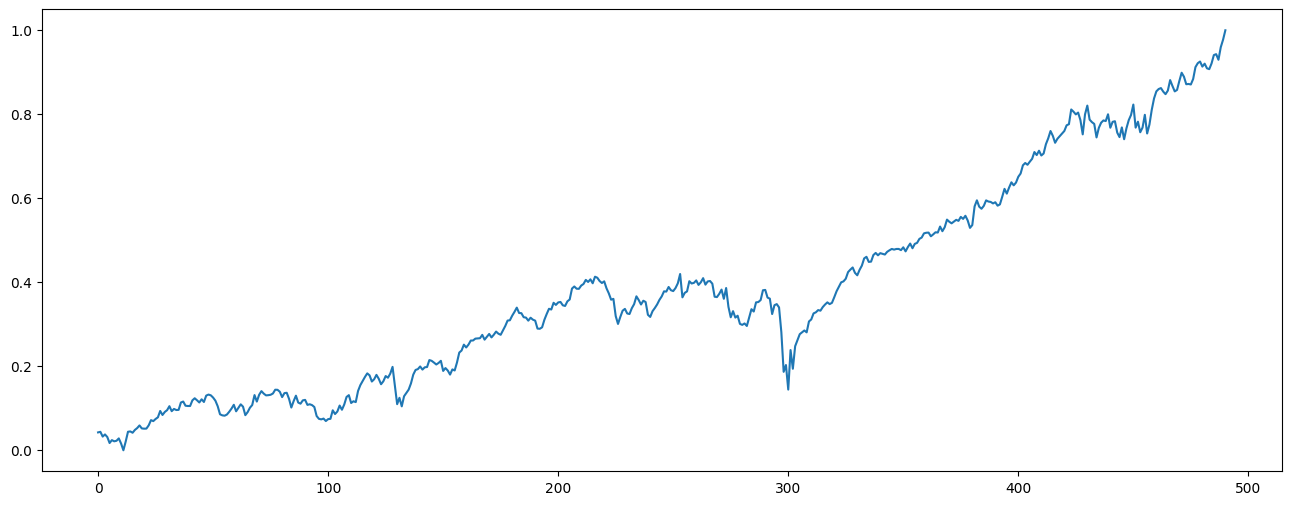

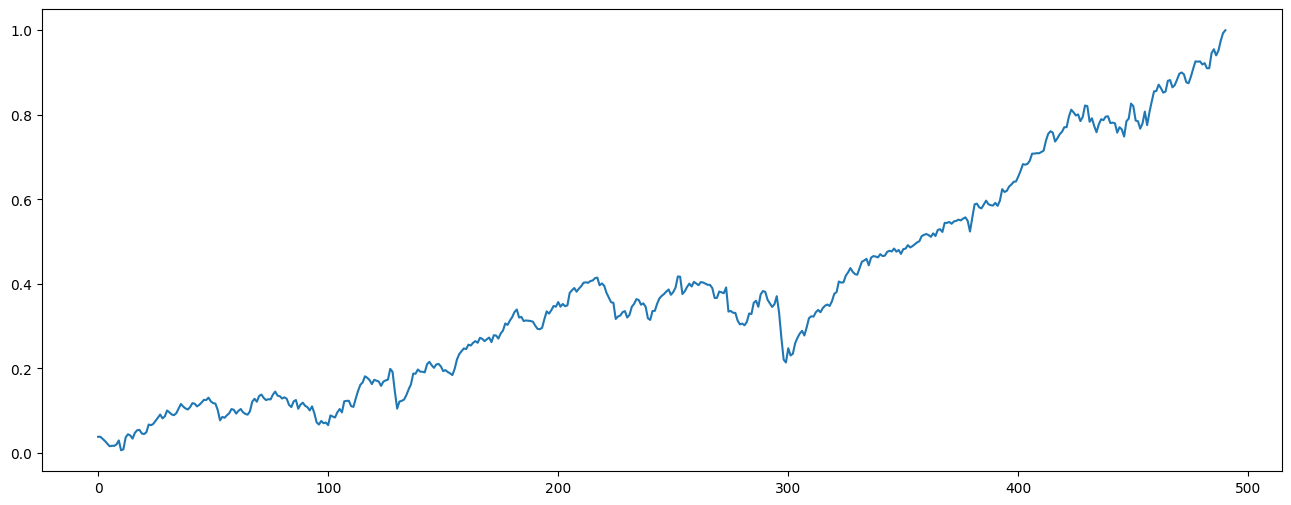

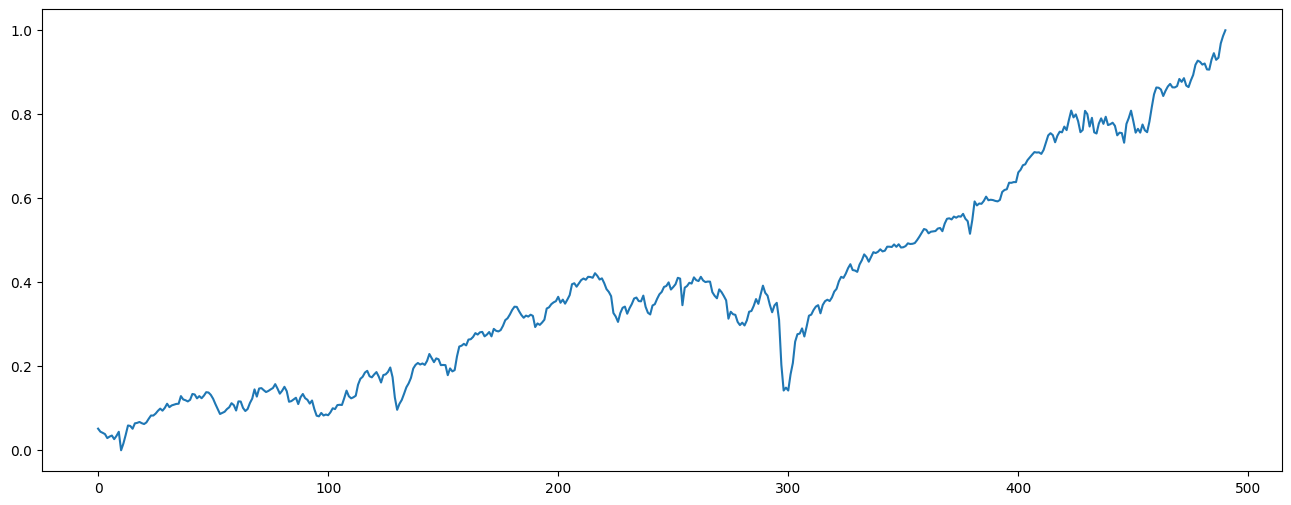

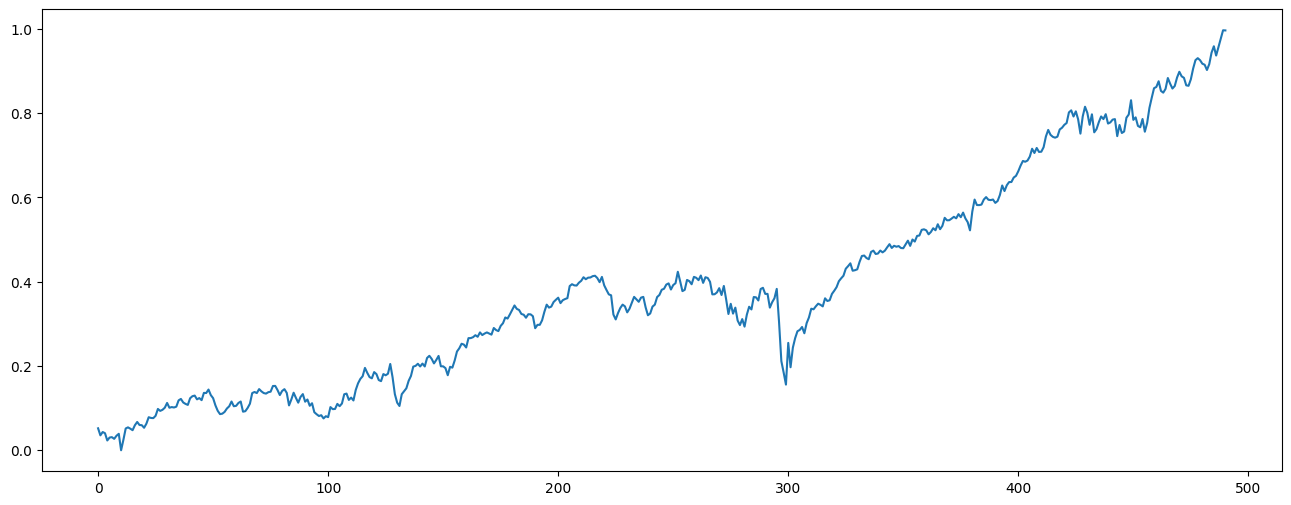

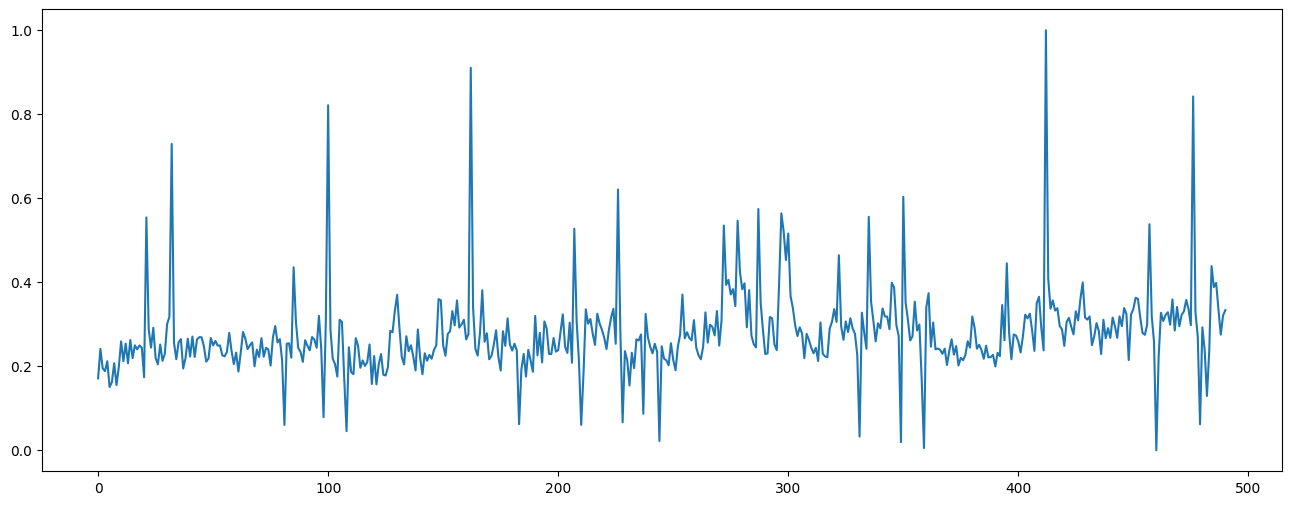

In [ ]:
for i in range(y.shape[1]):
  plt.figure(figsize=(16,6))
  plt.plot(y[:,i])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 267ms/step - loss: 0.9047 - mae: 0.6808 - rmse: 0.9153 - val_loss: 0.2359 - val_mae: 0.4416 - val_rmse: 0.4857
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - loss: 0.0626 - mae: 0.1995 - rmse: 0.2502 - val_loss: 0.2674 - val_mae: 0.4537 - val_rmse: 0.5171
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - loss: 0.0488 - mae: 0.1767 - rmse: 0.2210 - val_loss: 0.2216 - val_mae: 0.4223 - val_rmse: 0.4707
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 0.0450 - mae: 0.1680 - rmse: 0.2122 - val_loss: 0.2184 - val_mae: 0.4177 - val_rmse: 0.4673
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - loss: 0.0410 - mae: 0.1594 - rmse: 0.2024 - val_loss: 0.2014 - val_mae: 0.4015 - val_rmse: 0.4488
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - loss: 0.0428 - mae: 0.1625 - rmse: 0.2068 - val_loss: 0.2132 - val_mae: 0.4133 - val_rmse: 0.4618
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0388 - mae: 0.1565

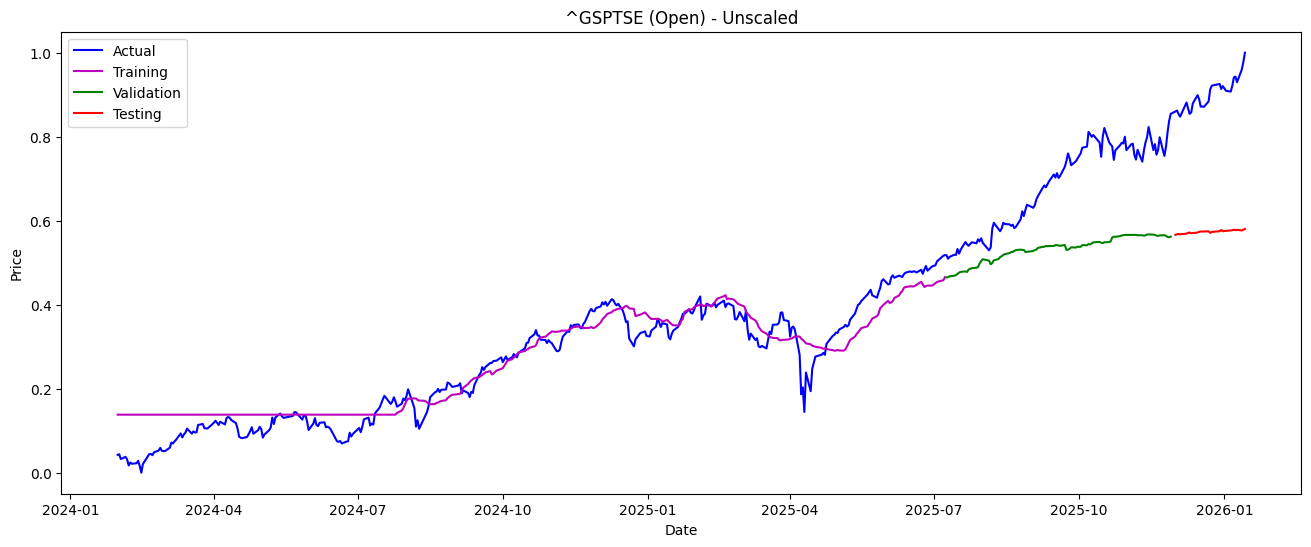

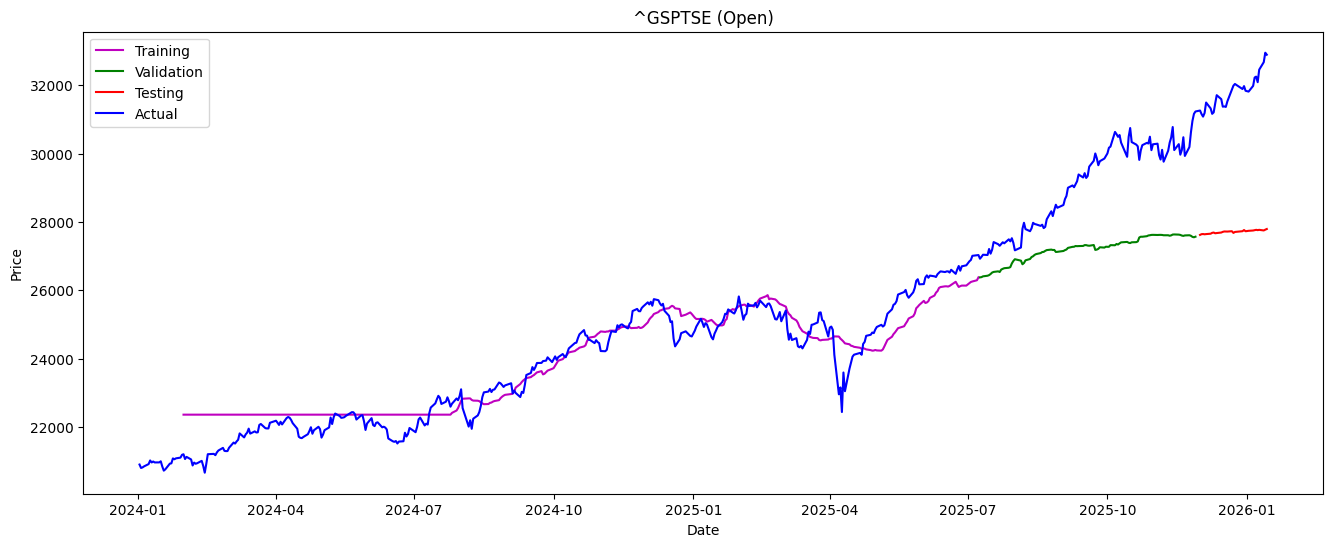

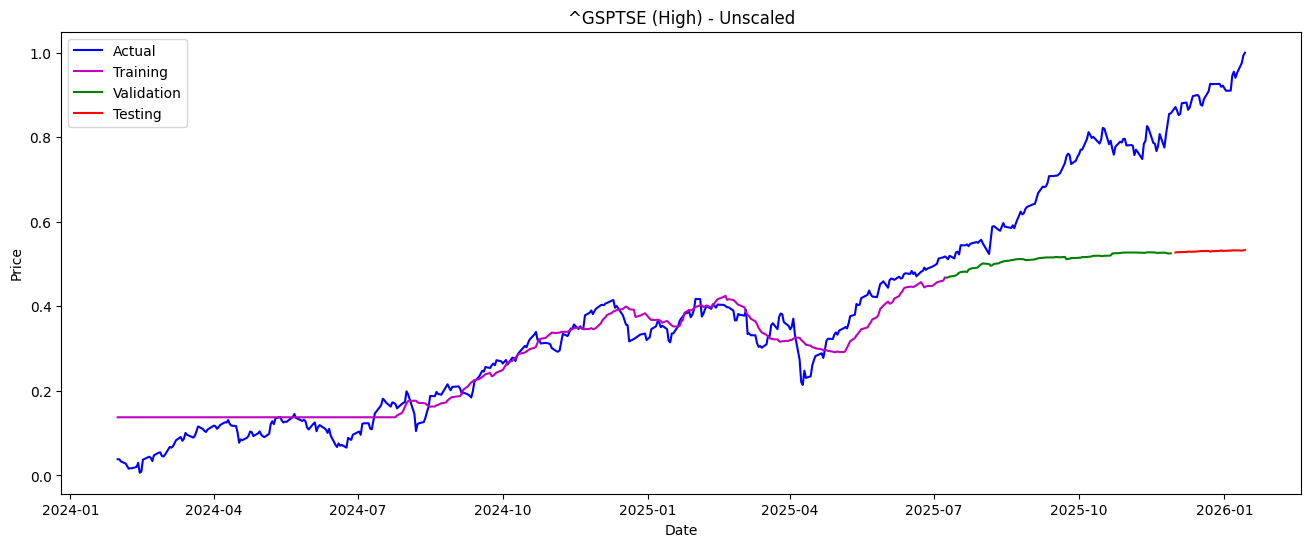

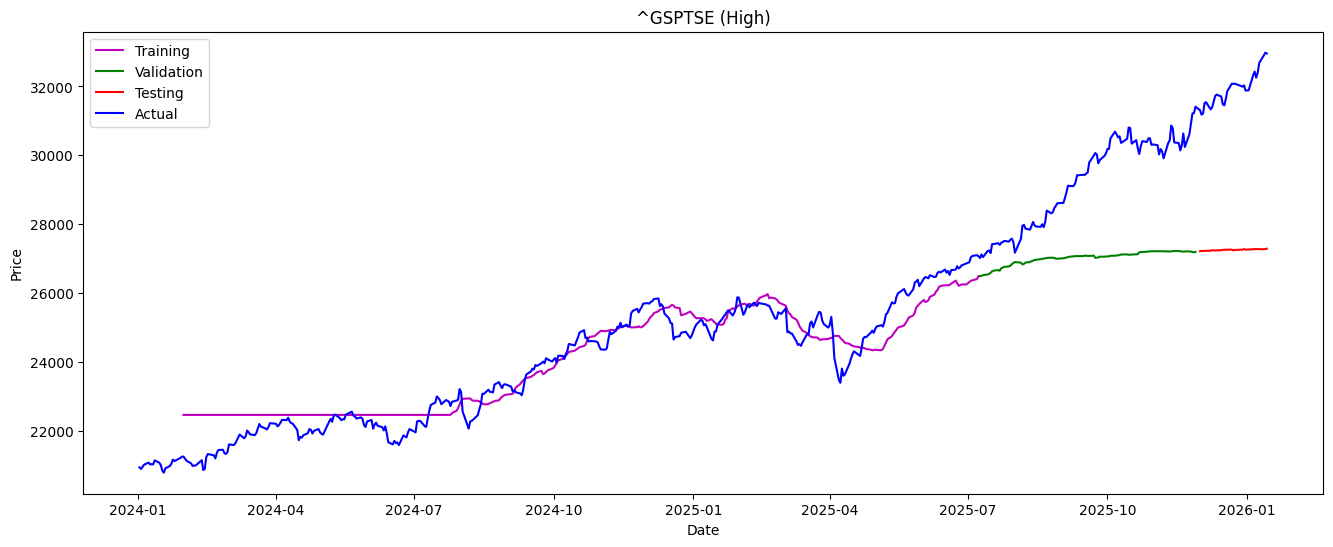

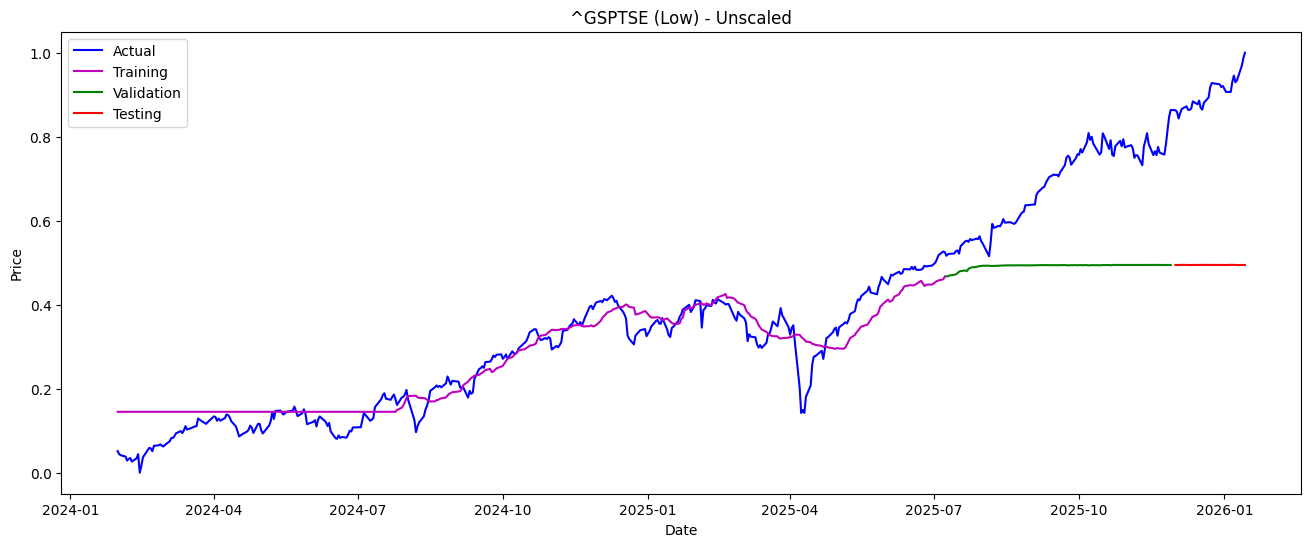

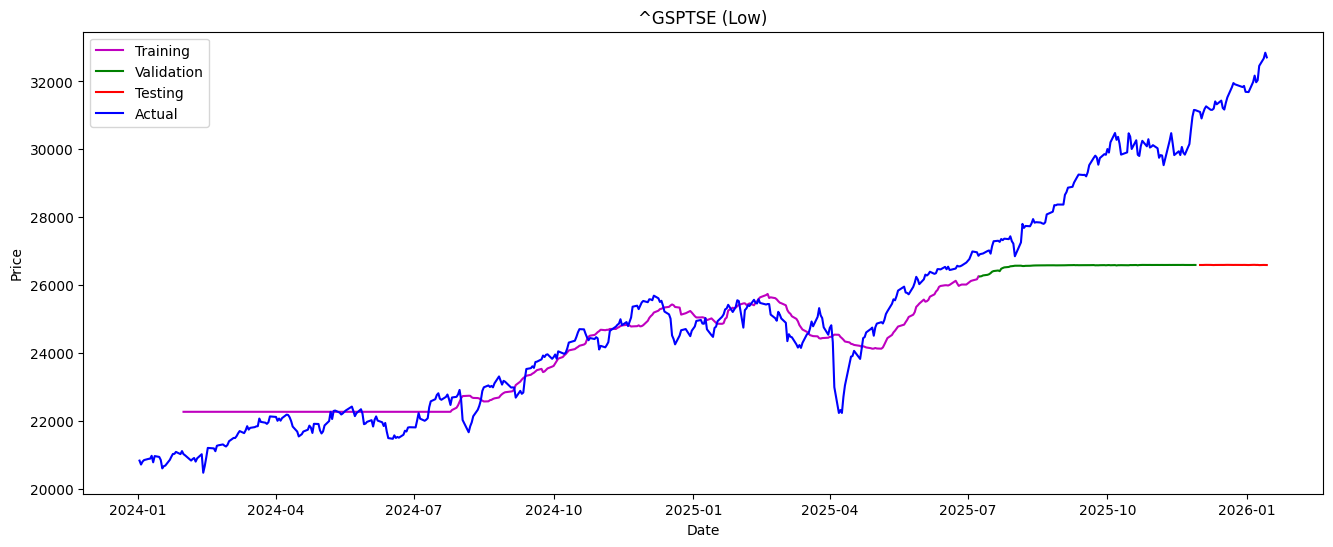

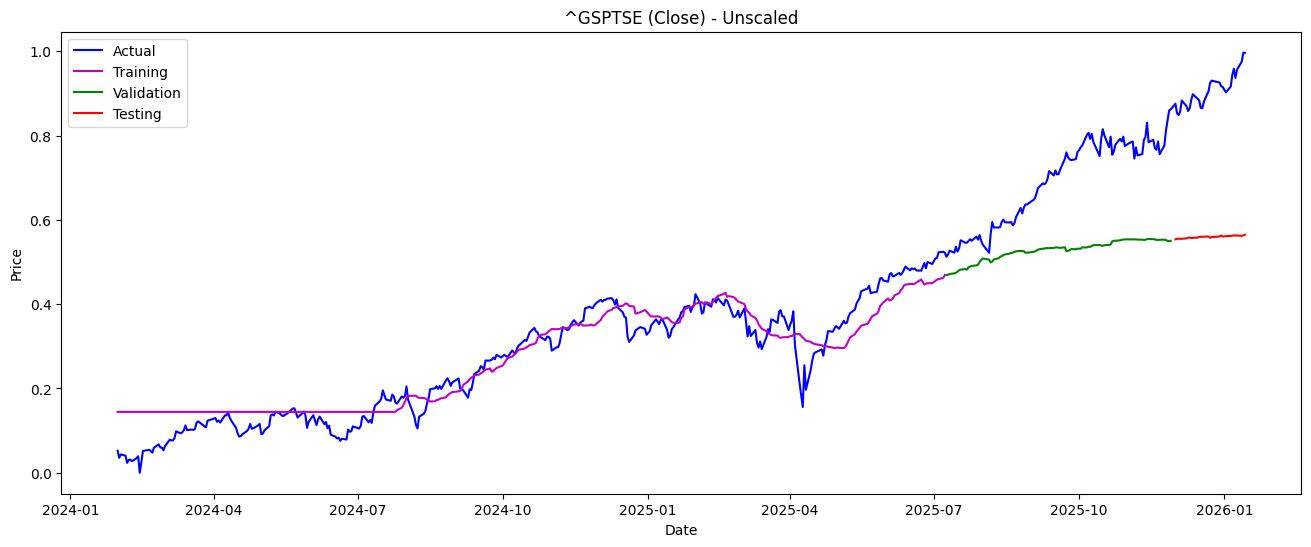

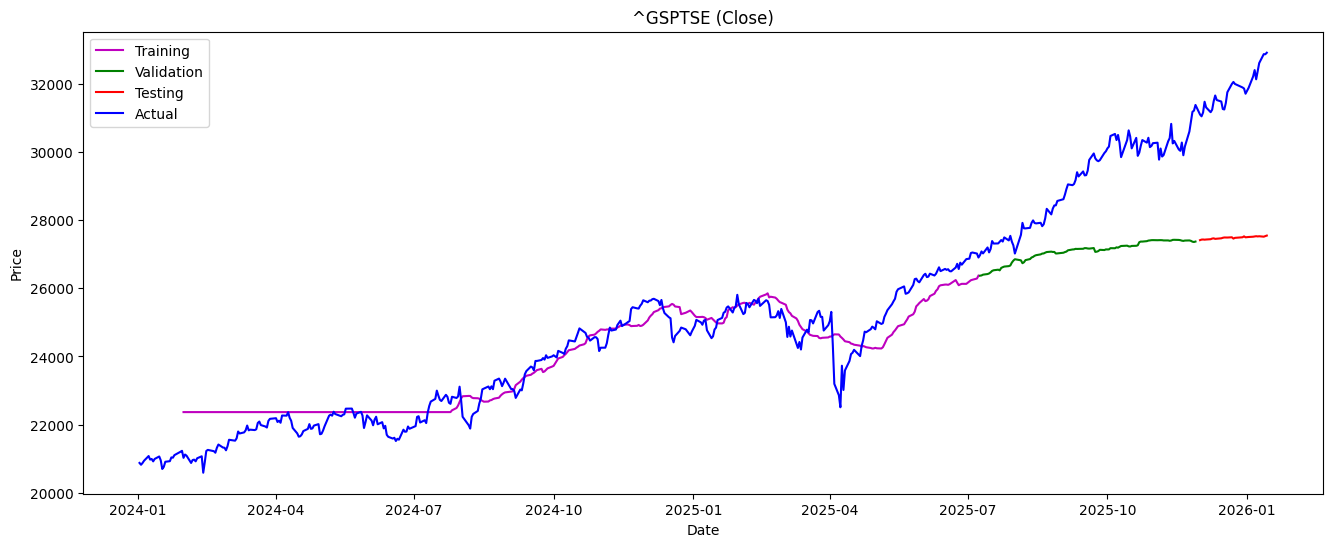

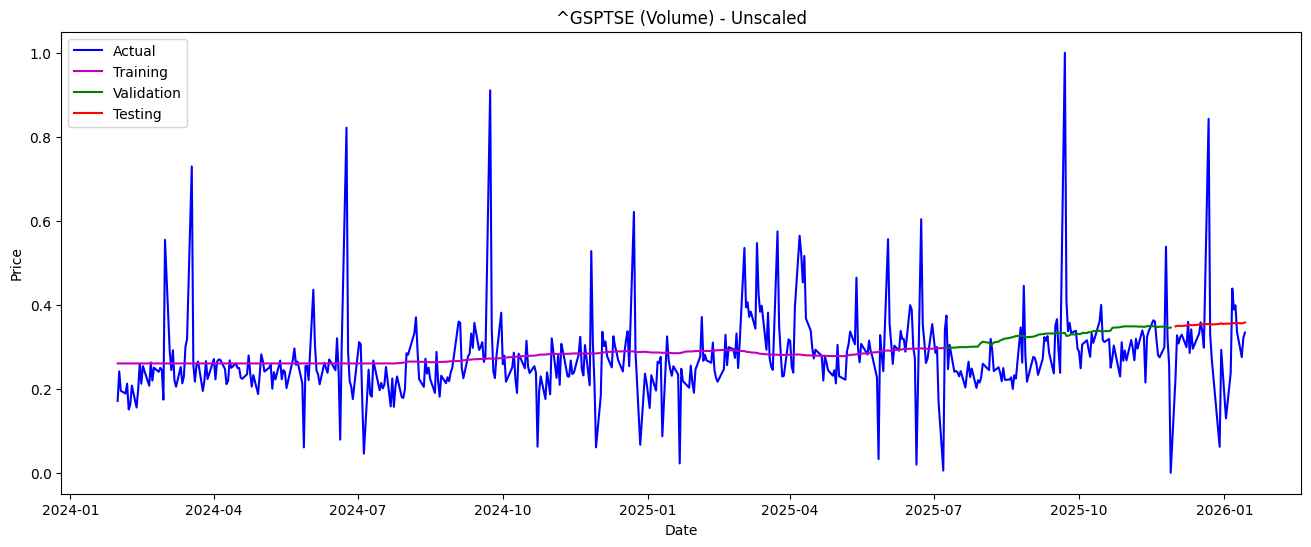

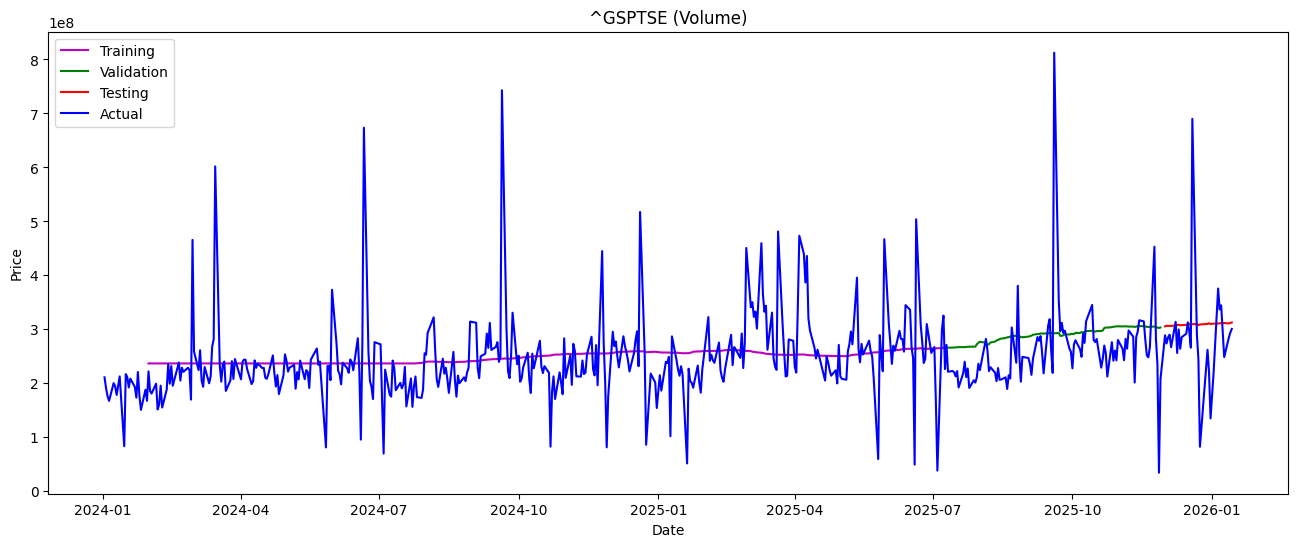

[2.187946582351265,
 2.6076747324260845,
 2.6360853895118086,
 2.3320296630738984,
 0.1568796651803133]

In [ ]:
embed_dim = 32  # Embedding size for each token
num_heads = 8  # Number of attention heads
ff_dim = 32  # Hidden layer size in feed forward network inside transformer
maxlen = X.shape[1]

valid_len = 100
test_len = 30
time_step = 20


NRMSE_list = transformer_model(X, y, min_list, max_list, valid_len, test_len, maxlen, embed_dim, num_heads, ff_dim, 42, 'Yes')
NRMSE_list

In [ ]:
stock_symbol = '^GSPTSE'
start_date = '2024-01-01'
end_date = '2026-01-15'
interval_val='1d'

valid_len = 100
test_len = 30
time_step = 20


## ------------------- Collecting historical stock data: ---------------------

stock = yf.Ticker(stock_symbol)
hist = stock.history(start=start_date, end=end_date, interval=interval_val)
hist.to_csv(f'{stock_symbol}_{start_date}_{end_date}.csv')
hist.tail()
cols_list = ['Open', 'High', 'Low', 'Close', 'Volume'] #['Close']

stock_data = hist[cols_list]


## ---------------- Performing min-max scaling: ---------------------
min_val = stock_data.head(60).min().tolist()
max_val = stock_data.head(60).max().tolist()

min_list_vals = [min_val[:] for _ in range(60)]
max_list_vals = [max_val[:] for _ in range(60)]


for i in range(40):
  min_val = stock_data.iloc[:i+60,:].min().tolist()
  max_val = stock_data.iloc[:i+60,:].max().tolist()
  min_list_vals.append(min_val)
  max_list_vals.append(max_val)

for i in range(len(stock_data)-100):
  min_val = stock_data.iloc[i:i+100,:].min().tolist()
  max_val = stock_data.iloc[i:i+100,:].max().tolist()
  min_list_vals.append(min_val)
  max_list_vals.append(max_val)

# min_val = stock_data.head(20).min().tolist()
# max_val = stock_data.head(20).max().tolist()

# min_list_vals = [min_val[:] for _ in range(20)]
# max_list_vals = [max_val[:] for _ in range(20)]

# for i in range(len(stock_data)-20):
#   min_val = stock_data.iloc[i:i+20,:].min().tolist()
#   max_val = stock_data.iloc[i:i+20,:].max().tolist()
#   min_list_vals.append(min_val)
#   max_list_vals.append(max_val)


min_list = pd.DataFrame()
max_list = pd.DataFrame()

min_list = pd.DataFrame(min_list_vals, columns = cols_list)
max_list = pd.DataFrame(max_list_vals, columns = cols_list)

min_list.index = stock_data.index
max_list.index = stock_data.index

data_scaled = (stock_data - min_list)/(max_list - min_list)
data_scaled

## ---------------- Creating training and testing data: -----------------------
X, y = create_dataset(data_scaled, time_step=time_step)
X.shape


X_train = X[:-test_len - valid_len]
y_train = y[:-test_len - valid_len]


X_valid = X[-test_len - valid_len:-test_len]
y_valid = y[-test_len - valid_len:-test_len]

X_test = X[-test_len:]
y_test = y[-test_len:]

y_test

array([[1.0161822 , 1.04379564, 0.99835311, 1.03863135, 0.22279682],
       [1.00654608, 0.97673325, 0.98631758, 0.9362884 , 0.32719297],
       [0.97573215, 0.94687428, 0.94186102, 0.92355126, 0.30772083],
       [0.95779404, 0.95413309, 0.97778327, 0.94904164, 0.32220165],
       [0.9827061 , 1.02571118, 1.00700336, 1.02173089, 0.32871722],
       [1.05578233, 1.00490745, 1.01750224, 0.96271219, 0.29897757],
       [0.96102982, 0.9522345 , 0.97709544, 0.93098814, 0.35918499],
       [0.92349703, 0.96663642, 0.97643899, 0.94768032, 0.28506958],
       [0.93346457, 1.00306645, 0.98499405, 1.00298411, 0.34121987],
       [0.99410268, 1.03878268, 1.03290867, 1.03798207, 0.29527564],
       [1.049769  , 1.00784055, 0.9814625 , 0.97127365, 0.32271136],
       [0.97437858, 0.9882764 , 1.00519298, 0.96179151, 0.33096908],
       [0.92597817, 0.93894204, 0.95241339, 0.91448852, 0.35808522],
       [0.92758612, 0.93238311, 0.94260391, 0.91149294, 0.33607751],
       [0.92434784, 0.97295733, 0.

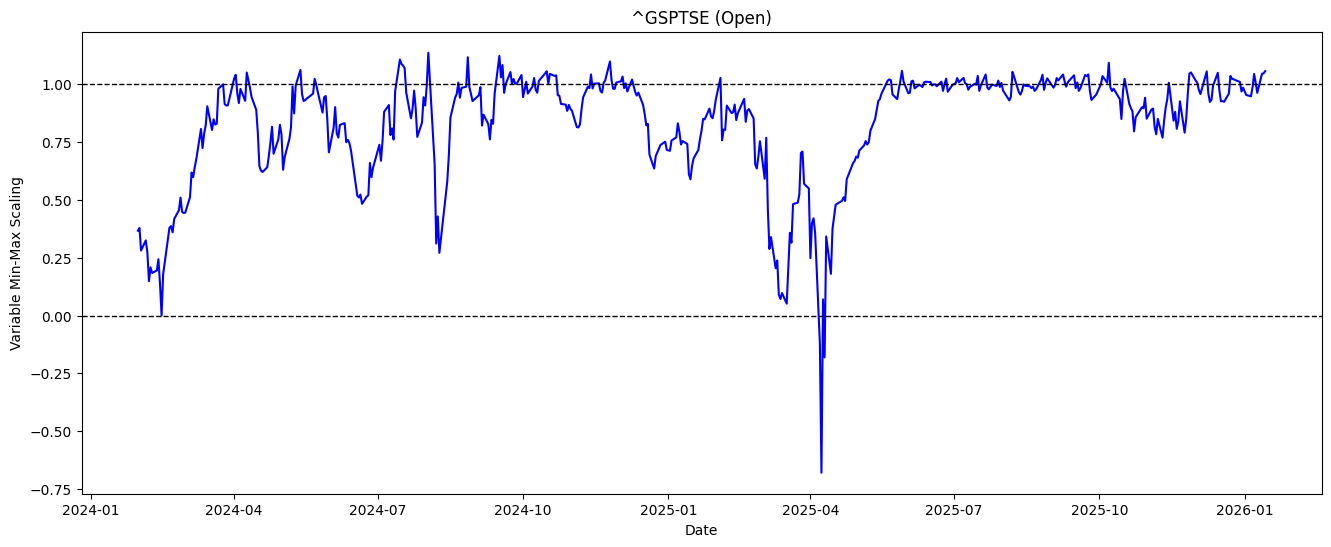

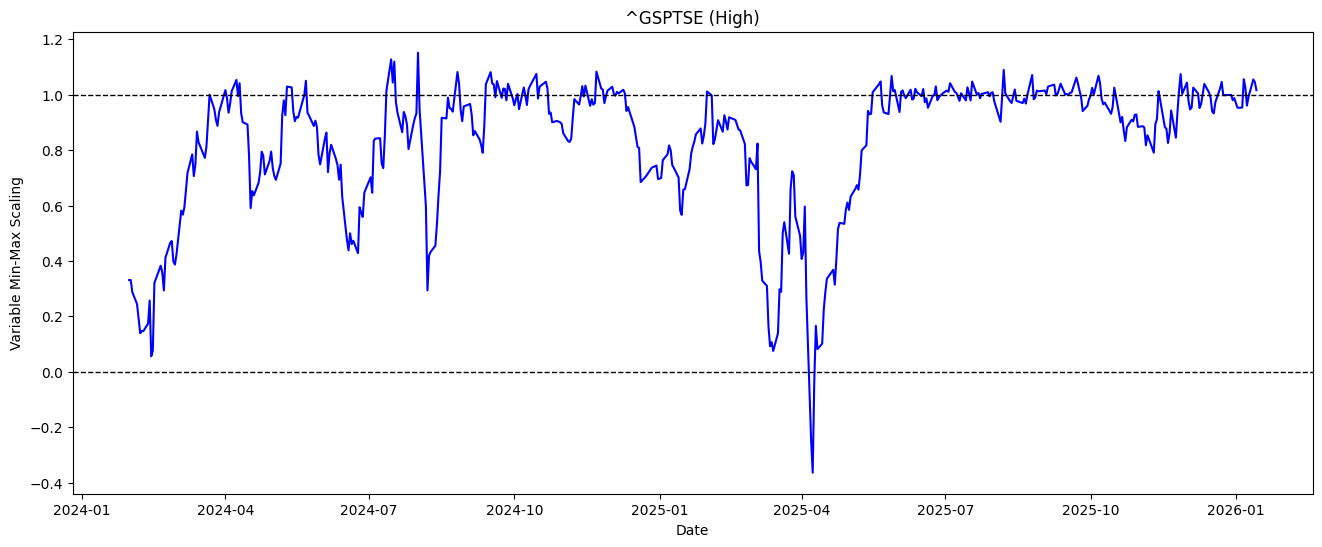

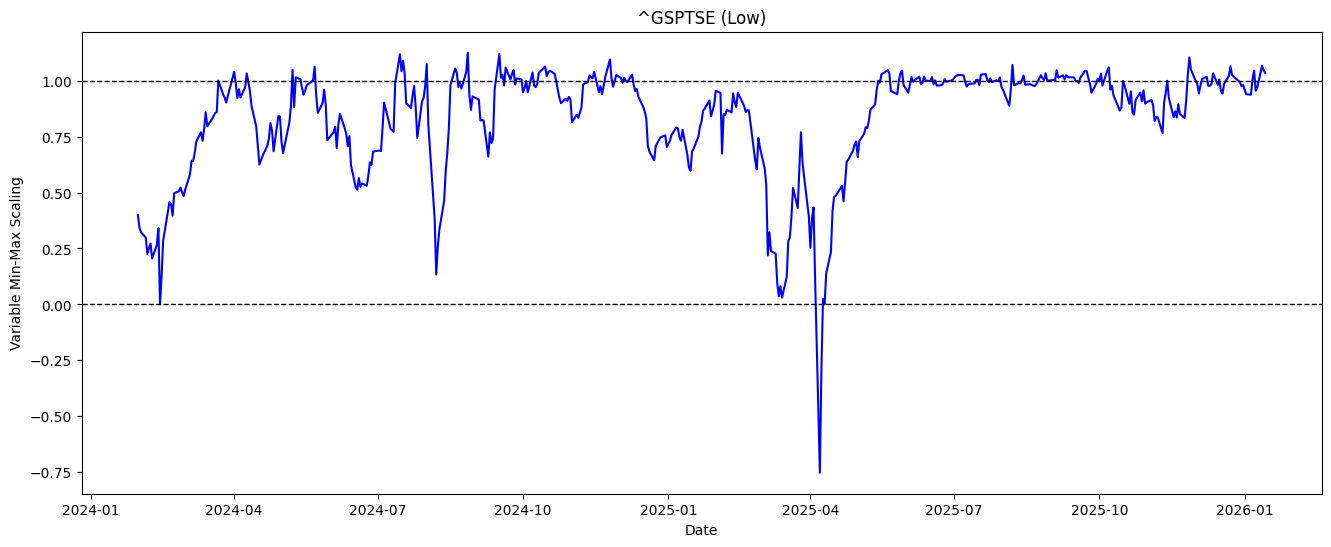

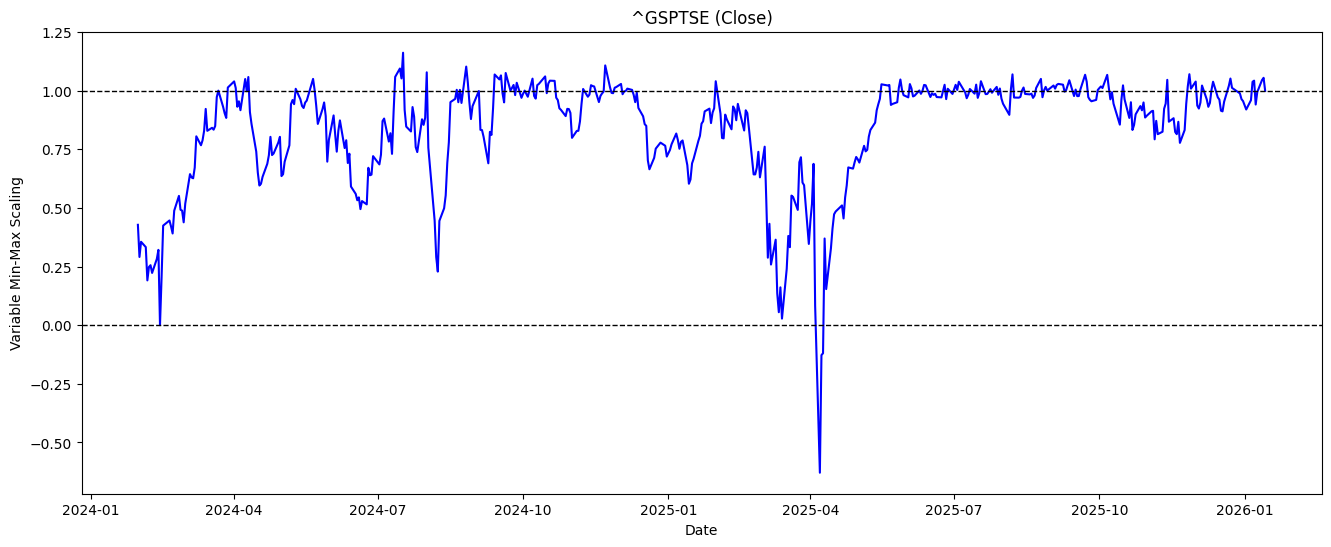

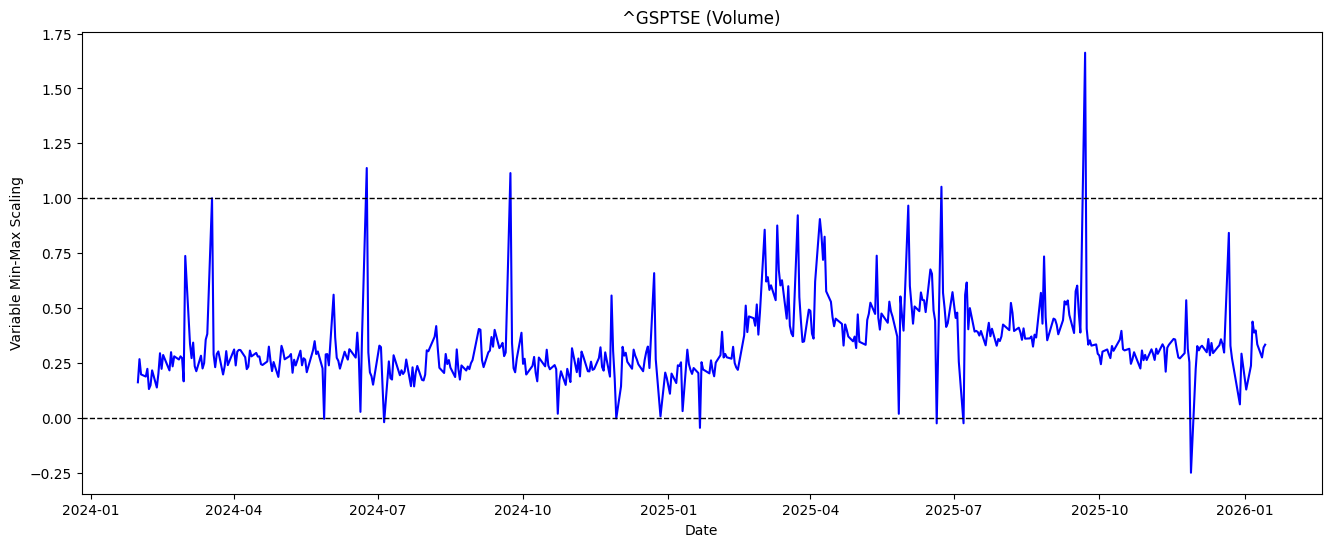

In [ ]:
for i in range(y.shape[1]):
  plt.figure(figsize=(16,6))
  plt.plot(stock_data[time_step+1:].index, y[:,i], 'b-')
  plt.axhline(y=1, color='k', linestyle='--', linewidth=1)
  plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
  plt.title(f'{stock_symbol} ({cols_list[i]})')
  plt.xlabel('Date')
  plt.ylabel('Variable Min-Max Scaling')

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 45s 238ms/step - loss: 1.3561 - mae: 0.8433 - rmse: 1.1235 - val_loss: 0.0884 - val_mae: 0.2414 - val_rmse: 0.2973
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - loss: 0.1917 - mae: 0.3513 - rmse: 0.4377 - val_loss: 0.0785 - val_mae: 0.2574 - val_rmse: 0.2802
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - loss: 0.1636 - mae: 0.3213 - rmse: 0.4043 - val_loss: 0.0613 - val_mae: 0.2210 - val_rmse: 0.2476
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - loss: 0.1249 - mae: 0.2780 - rmse: 0.3533 - val_loss: 0.0616 - val_mae: 0.2184 - val_rmse: 0.2482
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - loss: 0.1142 - mae: 0.2676 - rmse: 0.3379 - val_loss: 0.0549 - val_mae: 0.2063 - val_rmse: 0.2344
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - loss: 0.1267 - mae: 0.2753 - rmse: 0.3558 - val_loss: 0.0299 - val_mae: 0.1454 - val_rmse: 0.1729
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - loss: 0.1227 - mae: 0.2639

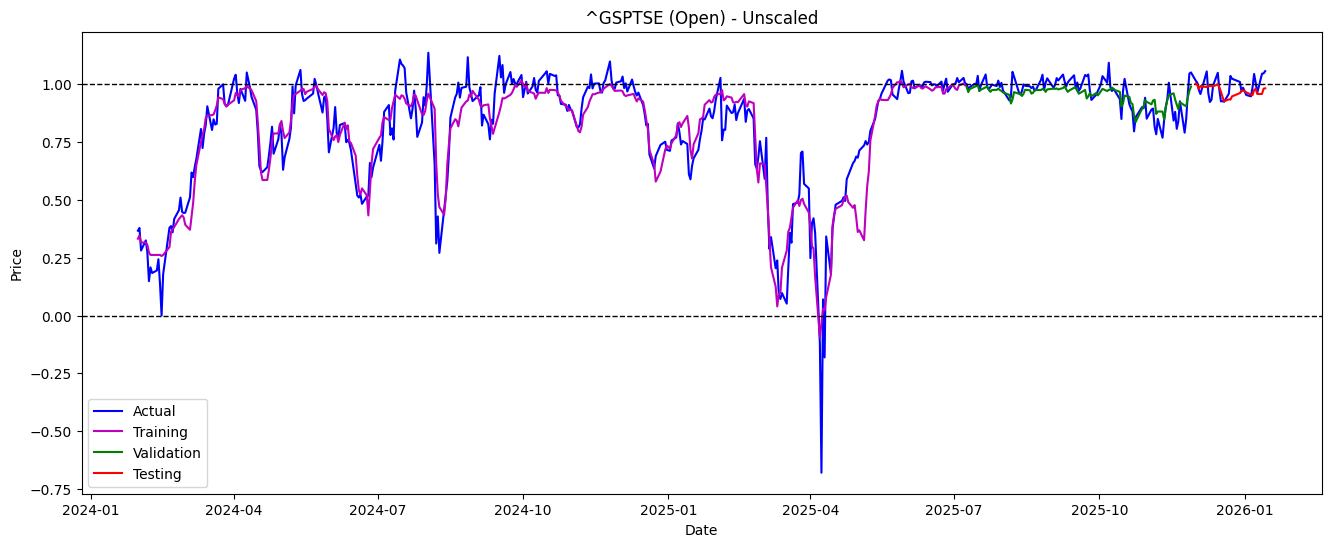

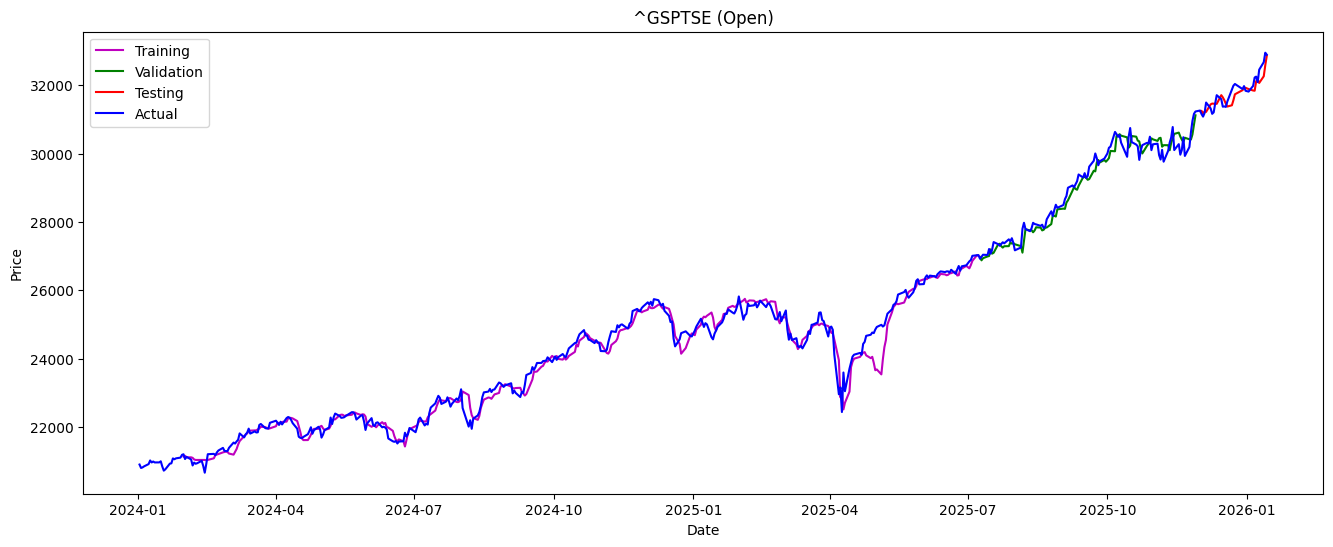

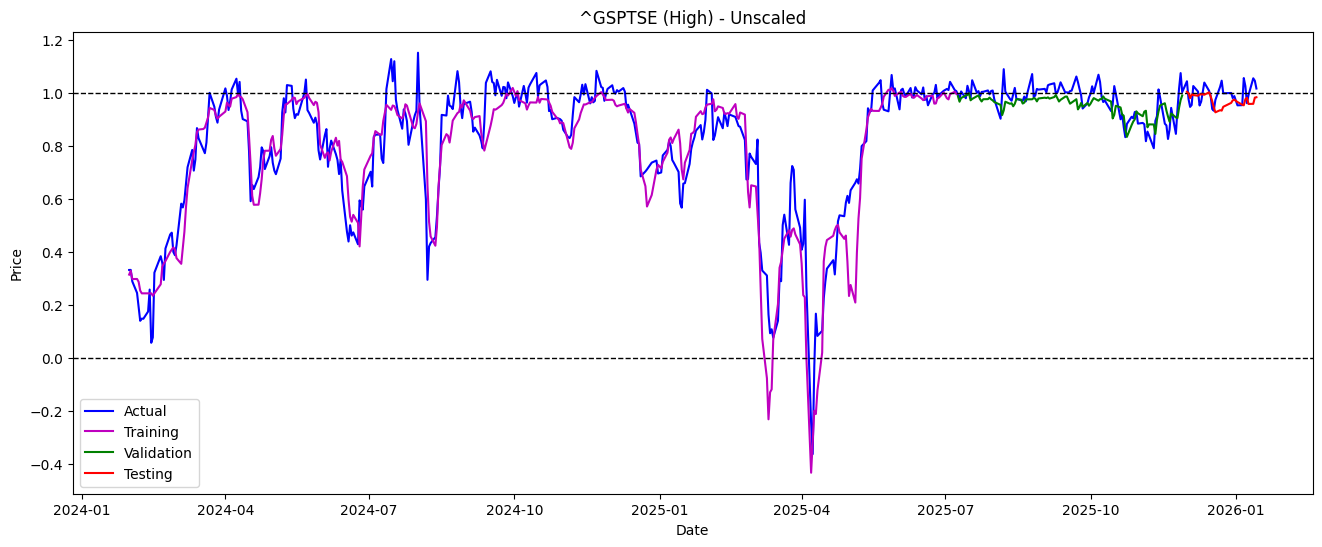

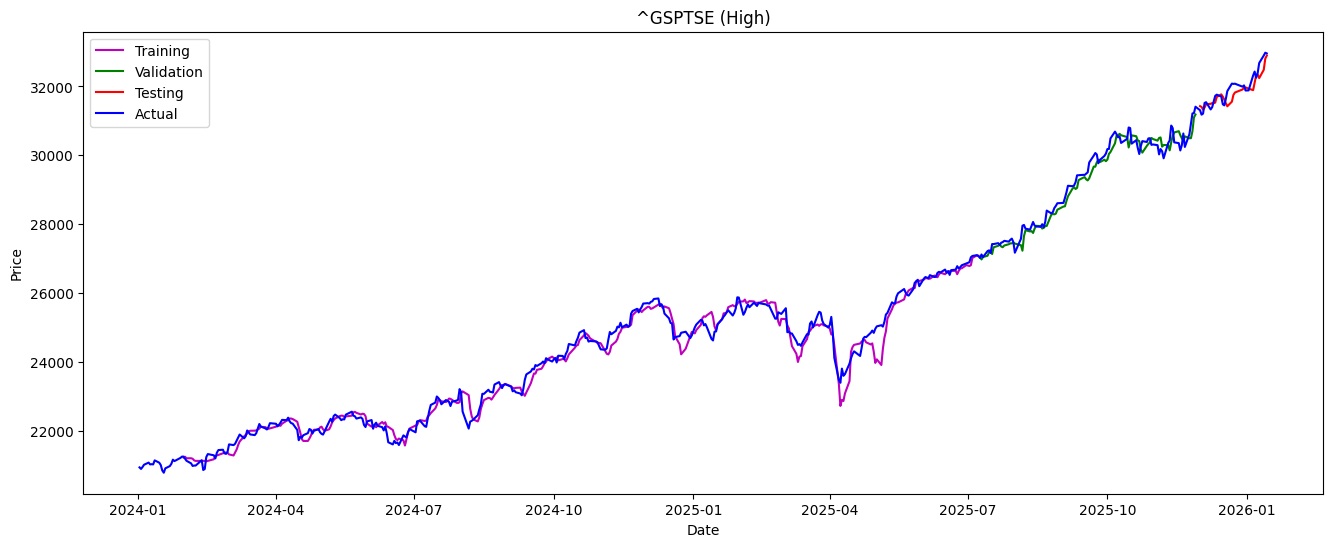

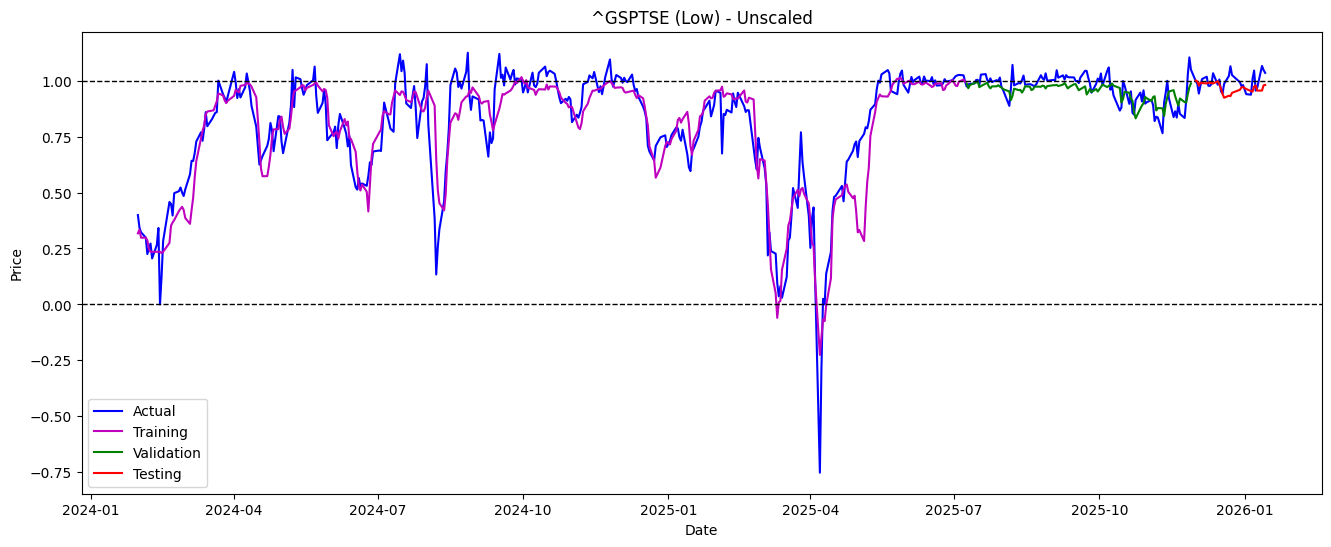

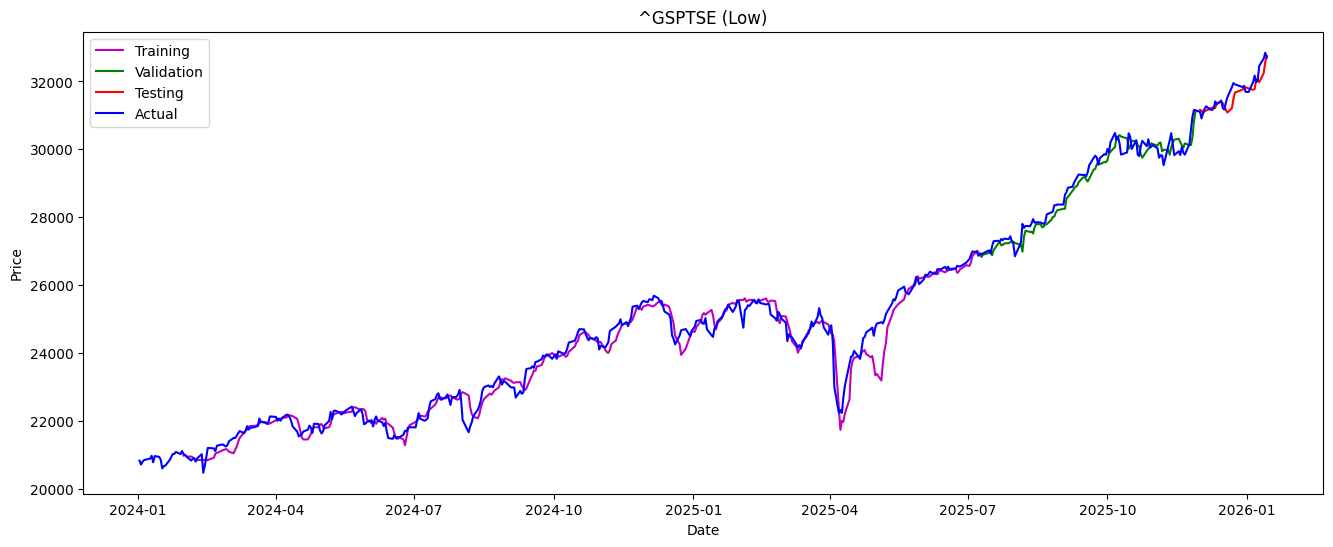

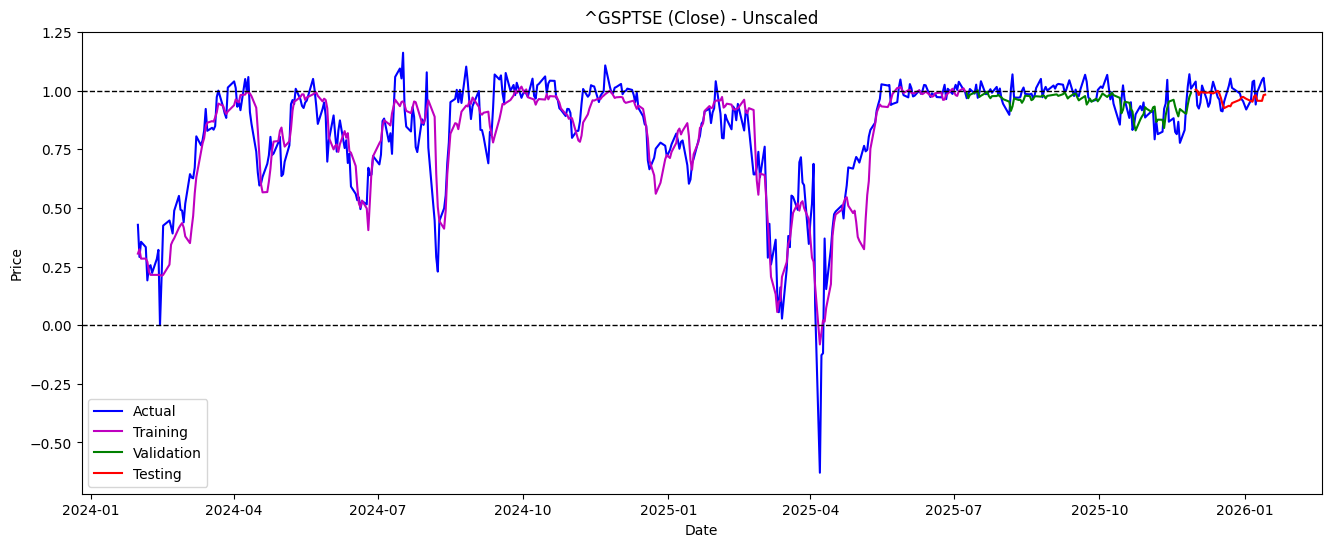

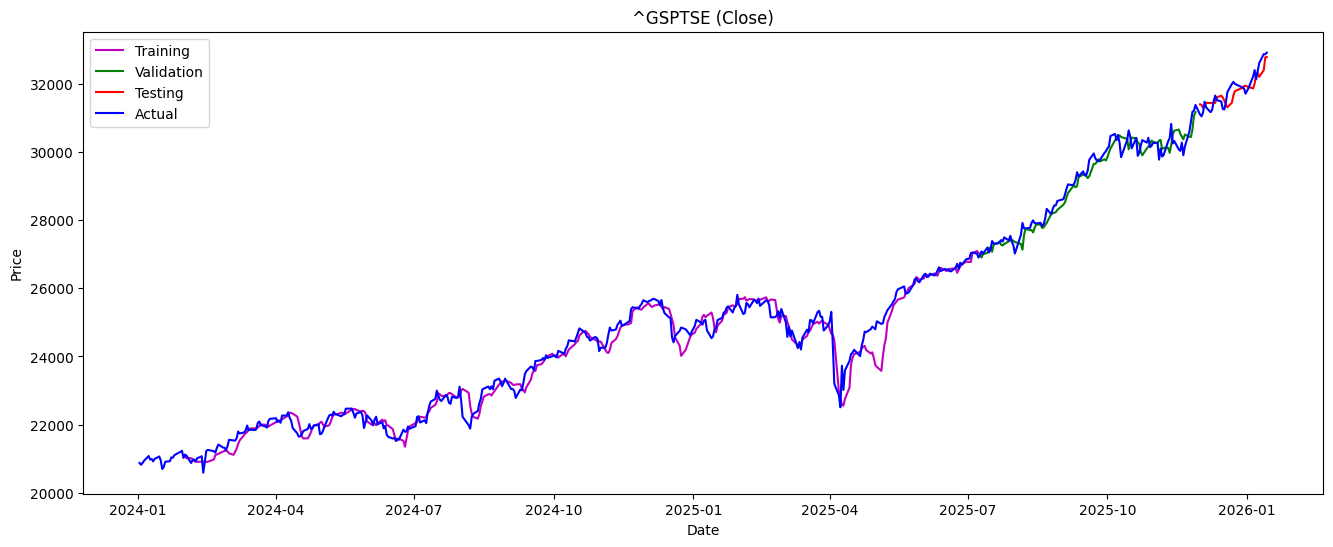

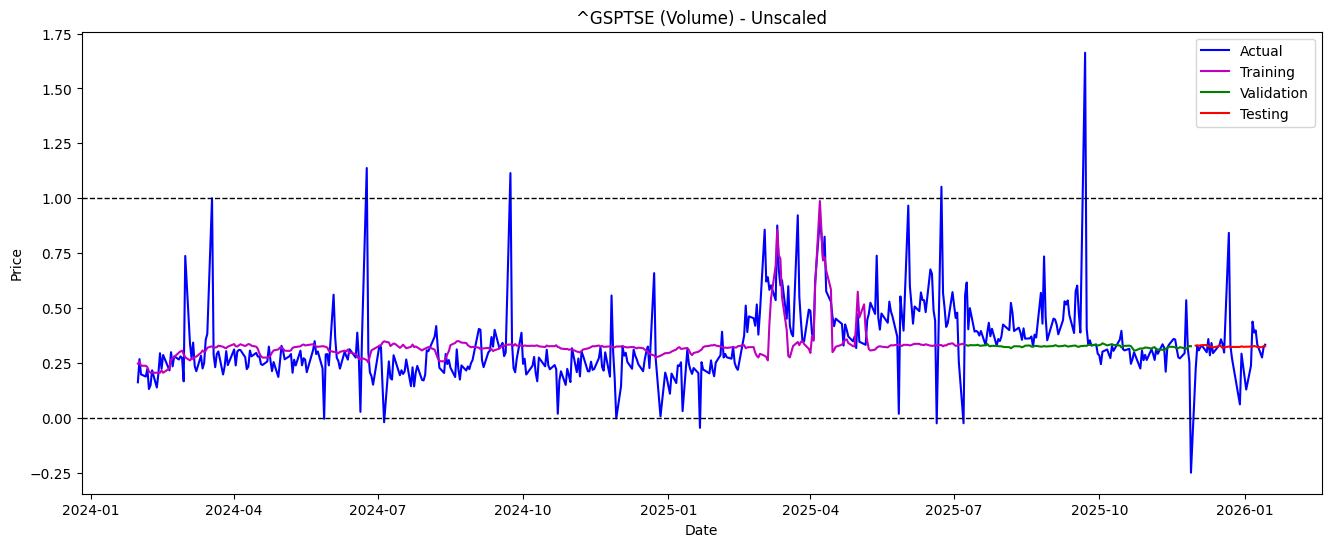

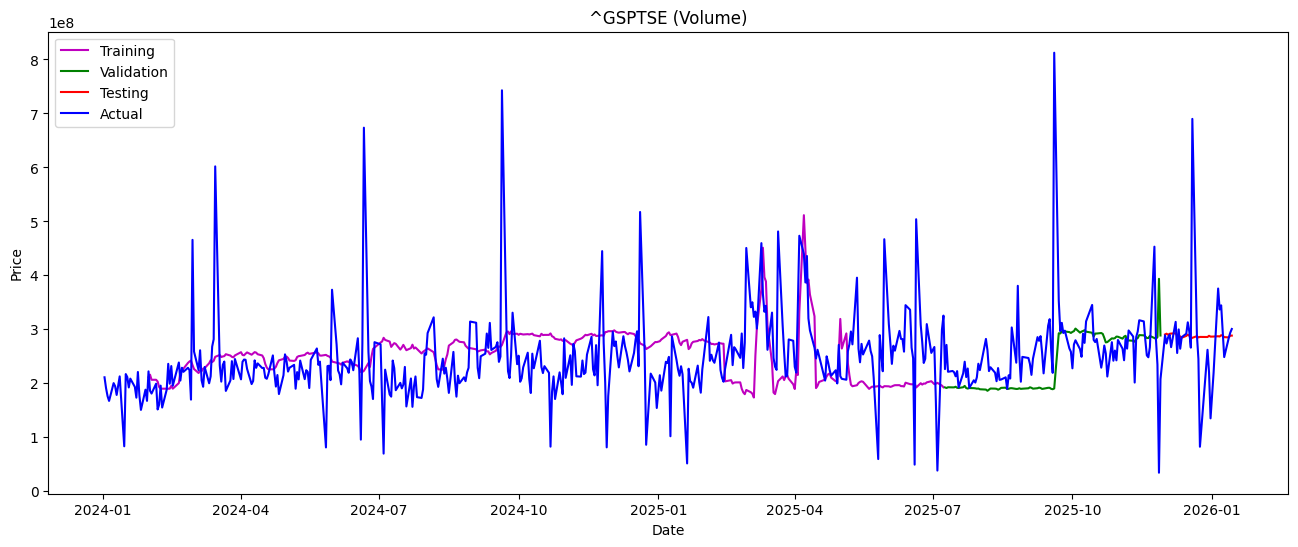

[0.1247588471322663,
 0.12963966333000584,
 0.12638896353013643,
 0.14191609314458478,
 0.152984394973292]

In [ ]:
embed_dim = 32  # Embedding size for each token
num_heads = 8  # Number of attention heads
ff_dim = 32  # Hidden layer size in feed forward network inside transformer
maxlen = X.shape[1]

valid_len = 100
test_len = 30
time_step = 20


NRMSE_list = transformer_model(X, y, min_list, max_list, valid_len, test_len, maxlen, embed_dim, num_heads, ff_dim, 42, 'Yes')
NRMSE_list

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 224ms/step - loss: 1.0624 - mae: 0.8013 - rmse: 1.0160 - val_loss: 0.1210 - val_mae: 0.2900 - val_rmse: 0.3479
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - loss: 0.2072 - mae: 0.3616 - rmse: 0.4548 - val_loss: 0.0604 - val_mae: 0.2219 - val_rmse: 0.2458
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.1633 - mae: 0.3152 - rmse: 0.4040 - val_loss: 0.0654 - val_mae: 0.2220 - val_rmse: 0.2557
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - loss: 0.1425 - mae: 0.2968 - rmse: 0.3774 - val_loss: 0.0690 - val_mae: 0.2420 - val_rmse: 0.2626
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.1348 - mae: 0.2866 - rmse: 0.3670 - val_loss: 0.0453 - val_mae: 0.1847 - val_rmse: 0.2129
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.1417 - mae: 0.2892 - rmse: 0.3762 - val_loss: 0.0315 - val_mae: 0.1495 - val_rmse: 0.1775
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - loss: 0.1338 - mae: 0.2884

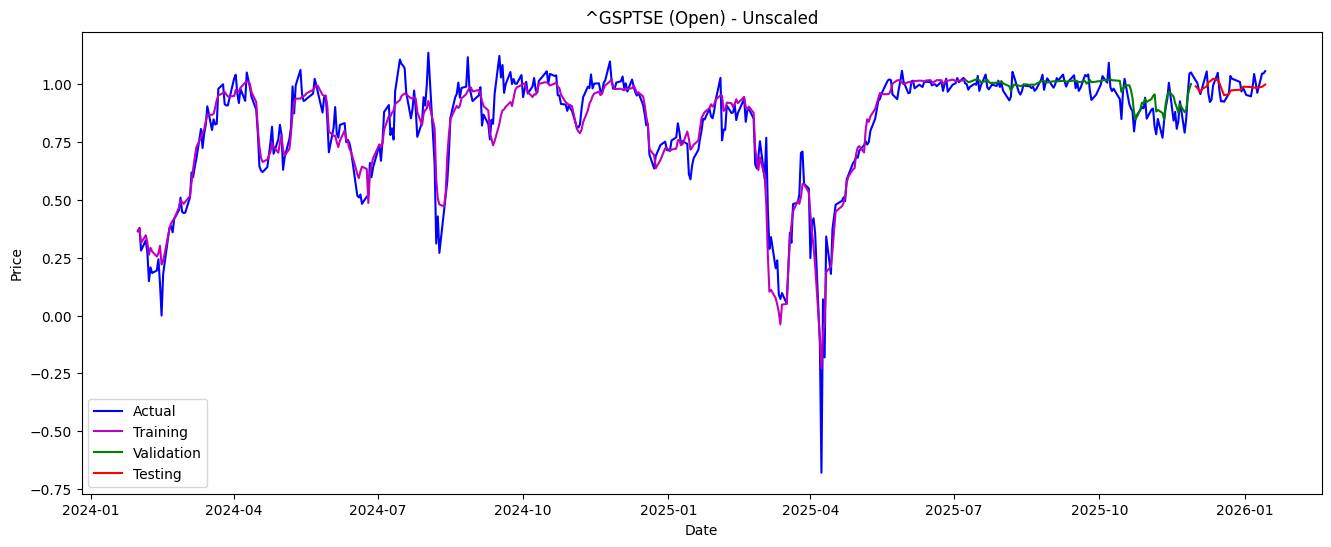

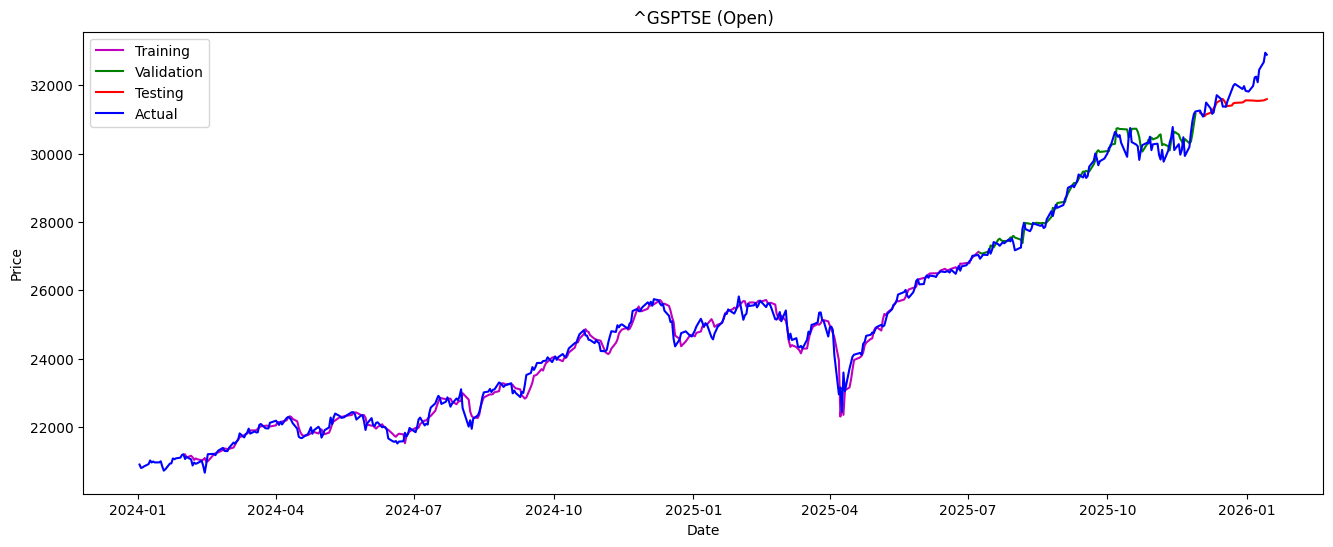

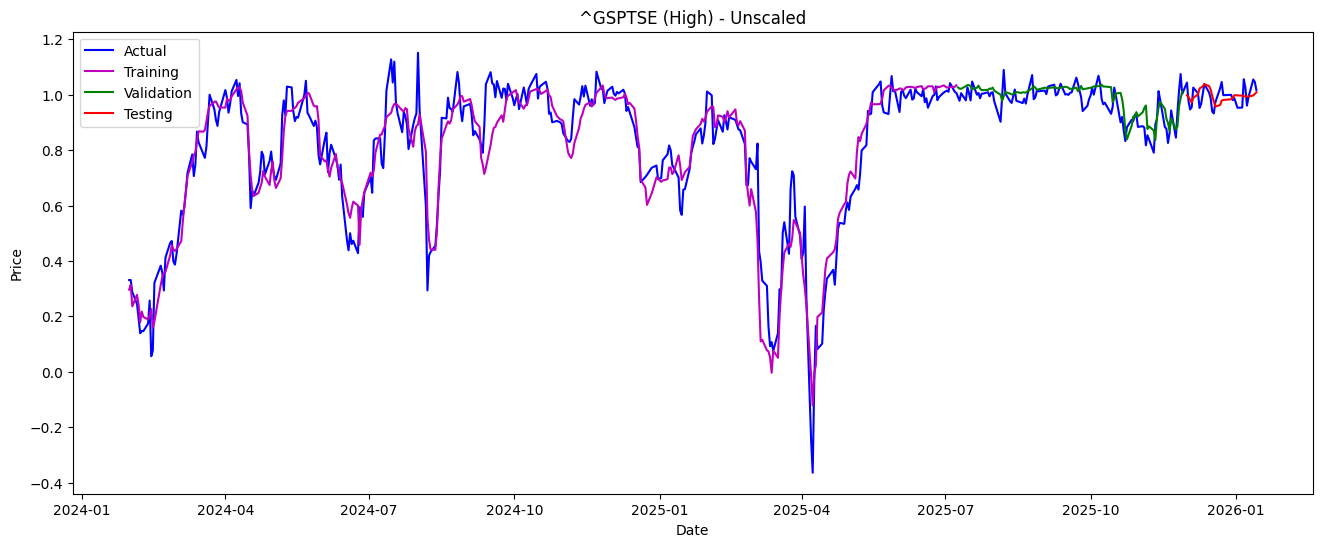

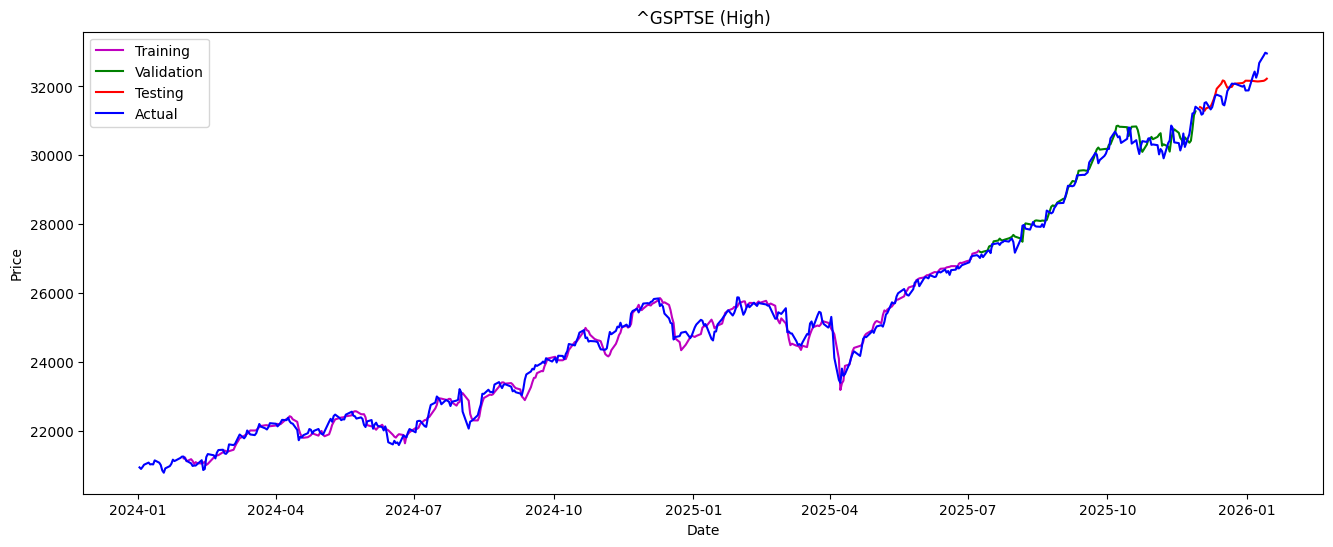

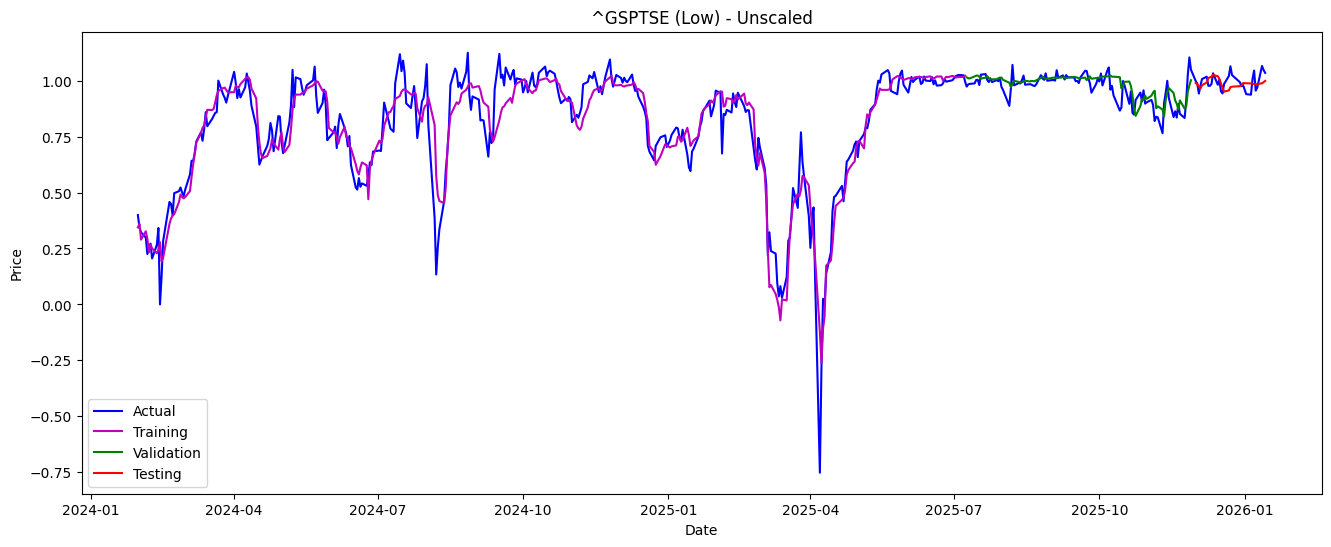

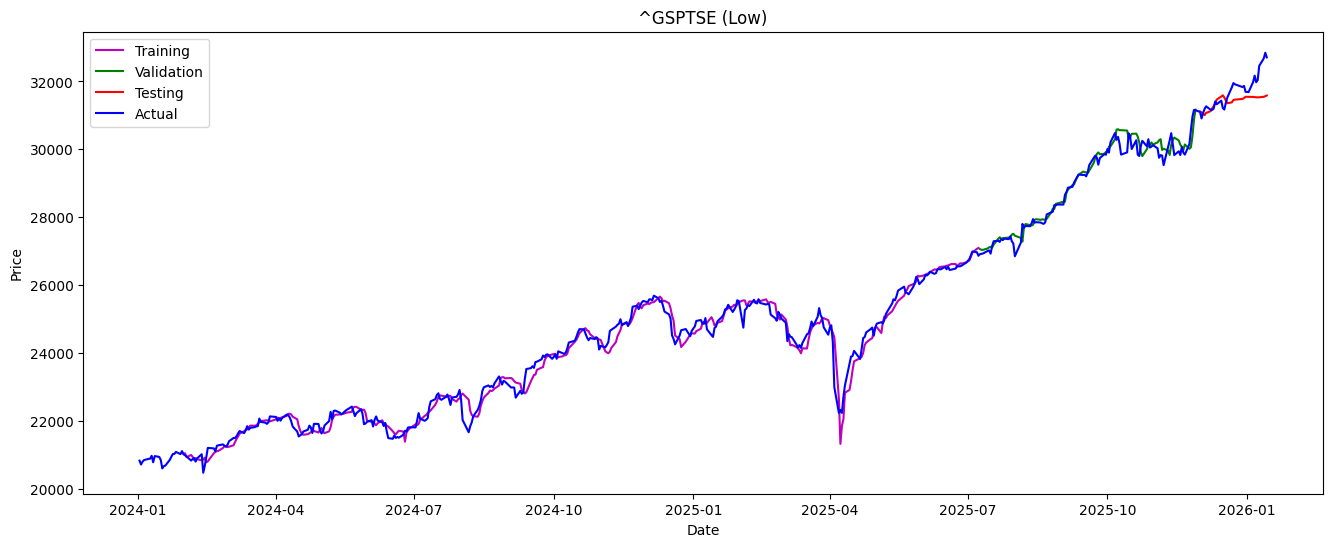

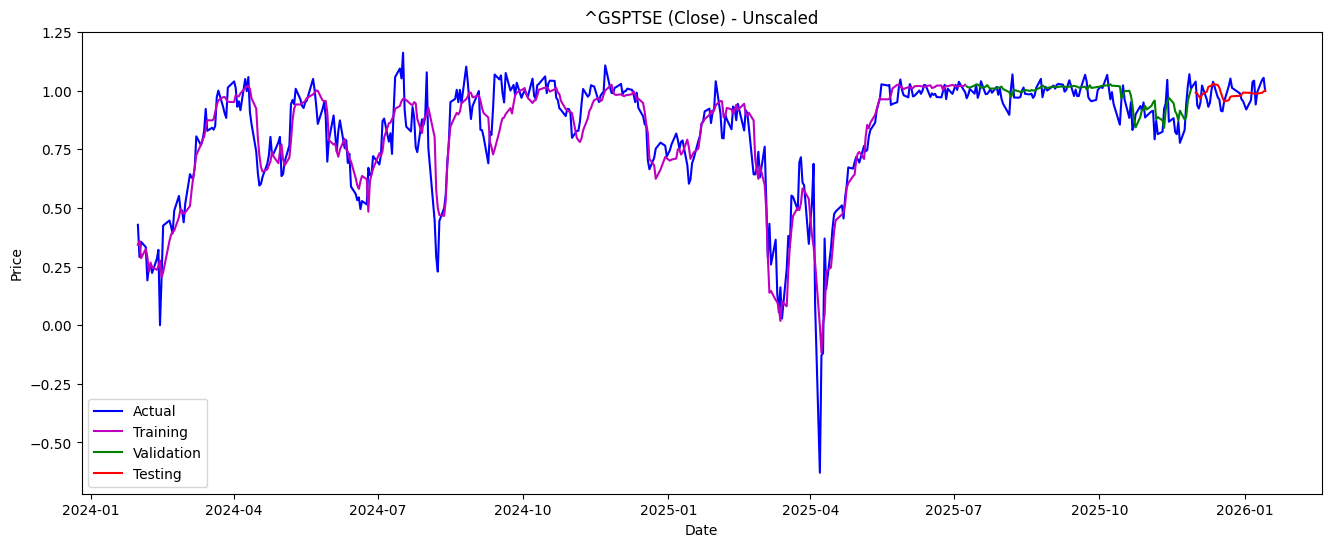

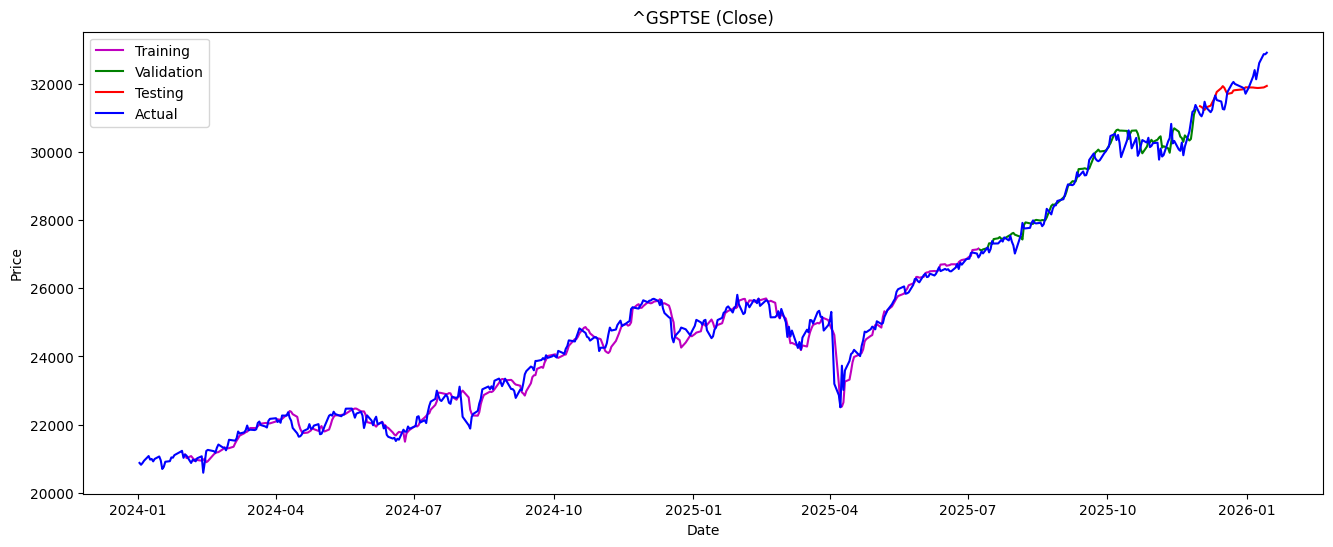

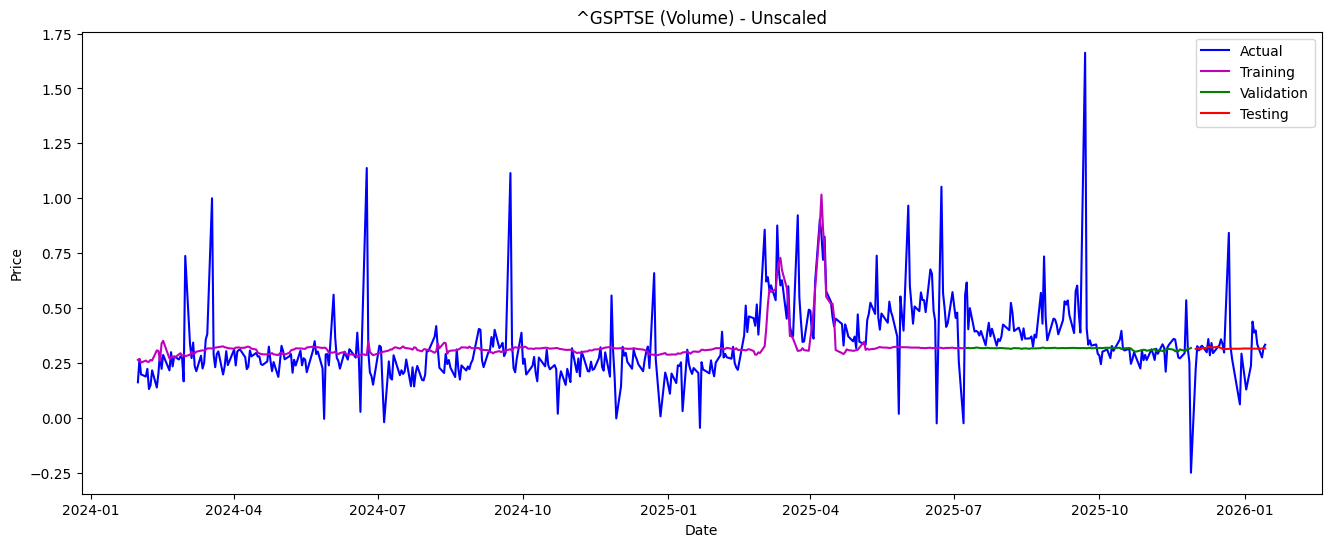

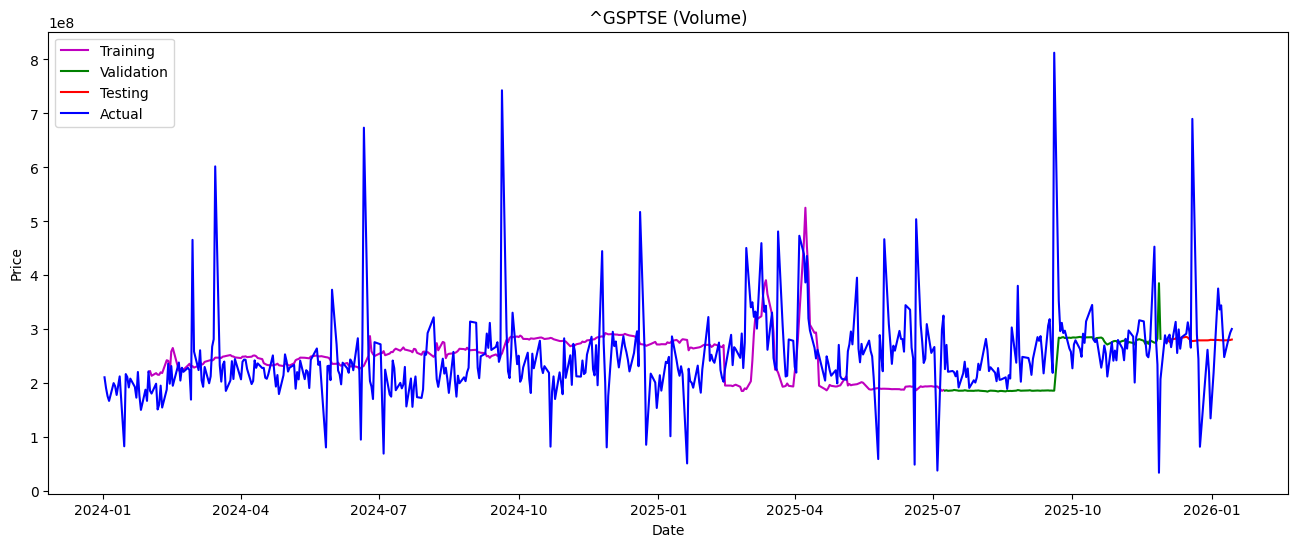

[0.28849848659248956,
 0.19917220278543424,
 0.2577029451514586,
 0.23378259496418669,
 0.15351051930379733]

In [ ]:
embed_dim = 32  # Embedding size for each token
num_heads = 8  # Number of attention heads
ff_dim = 32  # Hidden layer size in feed forward network inside transformer
maxlen = X.shape[1]

valid_len = 100
test_len = 30
time_step = 20


NRMSE_list = transformer_model_no_data(X, y, min_list, max_list, valid_len, test_len, maxlen, embed_dim, num_heads, ff_dim, 316, 'Yes')
NRMSE_list